# Metrics summary and comparison (in-repo notebook)

This notebook aggregates per-method DLKcat outputs and ESMFold structural metrics across the 1,423-enzyme held-out test set and renders the manuscript's Figure 3 panels (A: $\Delta\log_{10}(k_\mathrm{cat})$ distribution, B: structure / function / conservation heatmap, C: RL-round trade-off, D: SR@$\delta$ bars).

It expects the layout that `scripts/07_score_benchmark.sh` produces under `runs/benchmark_scores/<method>/{seed_<N>/*_kcatpred_dlkcat.csv, rmsd_plddt.csv}`. Method IDs match `catif_rl/evaluation/_method_registry.py`; the `Parameters` cell below is the only place that needs touching to point this notebook at a different score-dir layout.

Outputs (cells 11-17 below) are embedded as evidence of the figures / tables the manuscript reports; they were rendered against the author's local benchmark scores prior to release. Re-running cell 2 onwards against your own `runs/benchmark_scores/` regenerates them from your data.


## Parameters
Edit then run from top to bottom.

In [ ]:
# Parameter cell. Paths default to the repo's runs/ layout produced by
# scripts/07_score_benchmark.sh. Override BASE_DIR / RMSD_BASE_DIR if
# you have benchmark outputs in a different location (for instance, when
# re-running this notebook against the archived per-baseline FASTA outputs
# under the legacy `materials/05_baseline_outputs/` tree).
from pathlib import Path
import os

REPO_ROOT = Path(os.environ.get("CATIF_RL_REPO_ROOT", Path(__file__).resolve().parents[1])) if "__file__" in globals() else Path.cwd().parent
RUNS_DIR  = REPO_ROOT / "runs" / "benchmark_scores"
SUMMARY_DIR = RUNS_DIR / "per_method_summaries"
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

BASE_DIR      = str(RUNS_DIR)        # per-method DLKcat outputs live under <BASE_DIR>/<method>/seed_<N>/
RMSD_BASE_DIR = str(RUNS_DIR)        # per-method rmsd_plddt.csv lives at <RMSD_BASE_DIR>/<method>/rmsd_plddt.csv

# Method ids match catif_rl/evaluation/_method_registry.py.
# Each entry's globs and rmsd filename follow the manuscript filename
# convention: *_kcatpred_dlkcat.csv and rmsd_plddt.csv inside the method dir.
def _method(mid: str, recovery_glob: str | None = None) -> dict:
    return {
        "label": mid,
        "kcat_file_glob":     f"{mid}/seed_*/*_kcatpred_dlkcat.csv",
        "kcat_output_csv":    str(SUMMARY_DIR / f"{mid}_delta_lgKcat_summary.csv"),
        "recovery_file_glob": recovery_glob or f"{mid}/seed_*/*_kcatpred_dlkcat.csv",
        "recovery_output_csv": str(SUMMARY_DIR / f"{mid}_recovery_rate_summary.csv"),
        "rmsd_file_glob":     f"{mid}/rmsd_plddt.csv",
        "rmsd_output_csv":    str(SUMMARY_DIR / f"rmsd_plddt_{mid}_summary.csv"),
        "success_rmsd_column": "Backbone_RMSD",
        "success_rmsd_display_name": "Backbone_RMSD",
    }

MODEL_CONFIGS = {
    "catif_rl_r3":  _method("catif_rl_r3"),
    "catif_rl_r2":  _method("catif_rl_r2"),
    "catif_rl_r1":  _method("catif_rl_r1"),
    "catif":        _method("catif"),
    "gradeif":      _method("gradeif"),
    "enzymeif":     _method("enzymeif"),
    "pifold":       _method("pifold"),
    "proteinmpnn":  _method("proteinmpnn"),
    "ligandmpnn":   _method("ligandmpnn"),
    "esmif":        _method("esmif"),
    "abacust":      _method("abacust"),
}

# Iteration order for downstream summary tables / figures.
ACTIVE_MODEL_LABELS = [
    "catif_rl_r3", "catif_rl_r2", "catif_rl_r1",
    "catif", "gradeif", "enzymeif",
    "pifold", "proteinmpnn", "ligandmpnn", "esmif", "abacust",
]

PROID_COL = "ProID"
PROSEQ_COL = "ProSeq"
PROSEQ_PRIME_COL = "ProSeq'"

PLDDT_THRESHOLD = 90
RMSD_THRESHOLD = 4
DELTA_LGKCAT_THRESHOLD = 0
SR_DELTA_VALUES = [0, 0.25, 0.5, 1]
SR_THRESHOLD_CONFIGS = [
    {
        "label": f"{PLDDT_THRESHOLD}/{RMSD_THRESHOLD}/{delta}",
        "plddt": PLDDT_THRESHOLD,
        "rmsd": RMSD_THRESHOLD,
        "delta": delta,
    }
    for delta in SR_DELTA_VALUES
]


In [5]:
import glob
import os
from typing import Any, Dict, List

import pandas as pd


def _build_pattern(base_dir: str, glob_pattern: str) -> str:
    if os.path.isabs(glob_pattern):
        return glob_pattern
    return os.path.join(base_dir, glob_pattern)


def _normalize_kcat_columns(df: pd.DataFrame) -> pd.DataFrame:
    copy_df = df.copy()
    copy_df.columns = (
        copy_df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("-", "_")
    )
    return copy_df


def _normalize_rmsd_columns(df: pd.DataFrame) -> pd.DataFrame:
    copy_df = df.copy()
    copy_df.columns = (
        copy_df.columns.str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace("'", "", regex=False)
    )
    return copy_df


def _recovery_rate(seq_a: Any, seq_b: Any) -> float:
    seq_a, seq_b = str(seq_a), str(seq_b)
    if not seq_a or seq_a == "nan" or seq_b == "nan":
        return 0.0
    matches = sum(a == b for a, b in zip(seq_a, seq_b))
    return matches / len(seq_a) if seq_a else 0.0


def _compute_success_metrics(
    label: str,
    clean_df: pd.DataFrame,
    rmsd_clean_df: pd.DataFrame,
    sr_configs: List[Dict[str, Any]],
    rmsd_column: str,
    rmsd_display_name: str,
) -> Dict[str, Any]:
    if "proid" not in clean_df.columns:
        raise KeyError(f"[{label}] Column 'ProID' missing from kcat table after normalization.")
    if "proid" not in rmsd_clean_df.columns:
        raise KeyError(f"[{label}] Column 'ProID' missing from RMSD table after normalization.")

    kcat_per_proid = (
        clean_df[["proid", "delta_lgkcat", "_source_file"]]
        .dropna(subset=["proid", "delta_lgkcat"])
        .groupby("proid", as_index=False)
        .agg(
            mean_delta_lgkcat=("delta_lgkcat", "mean"),
            _source_file_kcat=("_source_file", "first"),
        )
    )

    rmsd_for_success = (
        rmsd_clean_df[["proid", "ca_rmsd", "backbone_rmsd", "avg_plddt", "_source_file"]]
        .dropna(subset=["proid", "ca_rmsd", "backbone_rmsd", "avg_plddt"])
        .drop_duplicates(subset=["proid"], keep="first")
        .rename(columns={"_source_file": "_source_file_rmsd"})
    )

    if rmsd_column not in rmsd_for_success.columns:
        raise KeyError(f"[{label}] Column '{rmsd_column}' missing for SR computation.")

    merged_success = pd.merge(kcat_per_proid, rmsd_for_success, on="proid", how="inner")
    total_samples = len(merged_success)

    success_detail_tables: Dict[str, pd.DataFrame] = {}
    sr_results: List[Dict[str, Any]] = []
    sr_threshold_labels: List[str] = []

    for cfg in sr_configs:
        cfg_label = cfg.get("label", f"{cfg['plddt']}/{cfg['rmsd']}/{cfg['delta']}").replace(" ", "")
        cfg_mask = (
            (merged_success["mean_delta_lgkcat"] > cfg["delta"])
            & (merged_success["avg_plddt"] > cfg["plddt"])
            & (merged_success[rmsd_column] < cfg["rmsd"])
        )
        cfg_success_count = int(cfg_mask.sum())
        cfg_success_rate = cfg_success_count / total_samples if total_samples else 0
        sr_results.append(
            {
                "model": label,
                "label": cfg_label,
                "plddt": cfg["plddt"],
                "rmsd": cfg["rmsd"],
                "delta_lgkcat": cfg["delta"],
                "success_count": cfg_success_count,
                "success_rate": cfg_success_rate,
                "total_samples": total_samples,
            }
        )
        sr_threshold_labels.append(cfg_label)

        detail_df = merged_success.copy()
        detail_df = detail_df.rename(
            columns={
                "mean_delta_lgkcat": "mean_delta_lgKcat",
                "avg_plddt": "avg_pLDDT",
                rmsd_column: rmsd_display_name,
            }
        )
        detail_df["delta_lgkcat_threshold"] = cfg["delta"]
        detail_df["pLDDT_threshold"] = cfg["plddt"]
        detail_df["RMSD_threshold"] = cfg["rmsd"]
        detail_df["is_success"] = cfg_mask.astype(int)
        detail_df = detail_df[
            [
                "proid",
                "mean_delta_lgKcat",
                "avg_pLDDT",
                rmsd_display_name,
                "delta_lgkcat_threshold",
                "pLDDT_threshold",
                "RMSD_threshold",
                "is_success",
                "_source_file_kcat",
                "_source_file_rmsd",
            ]
        ]
        success_detail_tables[cfg_label] = detail_df

    return {
        "merged_success": merged_success,
        "sr_results": sr_results,
        "success_detail_tables": success_detail_tables,
        "sr_threshold_labels": sr_threshold_labels,
        "total_samples": total_samples,
    }


def _summarize_recovery(label: str, config: Dict[str, Any]) -> Dict[str, Any]:
    pattern = _build_pattern(config.get("recovery_base_dir", BASE_DIR), config["recovery_file_glob"])
    recovery_paths = sorted(glob.glob(pattern, recursive=True))
    if not recovery_paths:
        raise FileNotFoundError(f"[{label}] No recovery files matched: {pattern}")

    rows = []
    for path in recovery_paths:
        sep = "\t" if path.lower().endswith(".tsv") else ","
        df_r = pd.read_csv(path, sep=sep)
        if PROID_COL not in df_r.columns:
            raise KeyError(f"[{label}] Column '{PROID_COL}' missing in {os.path.basename(path)}")
        if PROSEQ_COL not in df_r.columns or PROSEQ_PRIME_COL not in df_r.columns:
            raise KeyError(
                f"[{label}] Columns '{PROSEQ_COL}'/'{PROSEQ_PRIME_COL}' missing in {os.path.basename(path)}"
            )
        df_r = df_r.drop_duplicates(subset=[PROID_COL])
        recs = [
            _recovery_rate(a, b)
            for a, b in zip(df_r[PROSEQ_COL], df_r[PROSEQ_PRIME_COL])
        ]
        avg = sum(recs) / len(recs) if recs else 0.0
        rows.append(
            {
                "_source_file": os.path.basename(path),
                "proid_num": len(df_r),
                "avg_recovery_rate": avg,
            }
        )

    recovery_summary_df = pd.DataFrame(rows).sort_values("_source_file").reset_index(drop=True)
    avg_recovery = recovery_summary_df["avg_recovery_rate"].mean() if len(recovery_summary_df) else float("nan")
    recovery_proid_total = int(recovery_summary_df["proid_num"].sum()) if len(recovery_summary_df) else 0

    return {
        "recovery_summary_df": recovery_summary_df,
        "avg_recovery": avg_recovery,
        "recovery_proid_total": recovery_proid_total,
    }


def process_model(config: Dict[str, Any], sr_configs: List[Dict[str, Any]]) -> Dict[str, Any]:
    label = config["label"]

    pattern = _build_pattern(config.get("kcat_base_dir", BASE_DIR), config["kcat_file_glob"])
    file_paths = sorted(glob.glob(pattern, recursive=True))
    if not file_paths:
        raise FileNotFoundError(f"[{label}] No files matched: {pattern}")

    frames = []
    for path in file_paths:
        sep = "\t" if path.lower().endswith(".tsv") else ","
        df = pd.read_csv(path, sep=sep)
        df["_source_file"] = os.path.basename(path)
        frames.append(df)
    df = pd.concat(frames, ignore_index=True)
    df = _normalize_kcat_columns(df)

    if "delta_lgkcat" not in df.columns:
        raise KeyError(f"[{label}] Column 'delta_lgKcat' not found after normalization.")

    df["delta_lgkcat"] = pd.to_numeric(df["delta_lgkcat"], errors="coerce")
    clean_df = df.dropna(subset=["delta_lgkcat", "_source_file"])
    if clean_df.empty:
        raise ValueError(f"[{label}] No valid delta_lgKcat rows after cleaning.")

    summary_df = (
        clean_df.groupby("_source_file")["delta_lgkcat"]
        .agg(mean="mean", std="std", count="count")
        .reset_index()
        .sort_values("_source_file")
    )
    avg_mean = summary_df["mean"].mean()
    total_protein_substrate = int(summary_df["count"].sum())

    if "proid" not in clean_df.columns:
        raise KeyError(f"[{label}] Column 'ProID' missing from kcat table after normalization.")

    sequence_level_df = (
        clean_df[["_source_file", "proid", "delta_lgkcat"]]
        .dropna(subset=["_source_file", "proid", "delta_lgkcat"])
        .copy()
    )
    sequence_level_df["proid"] = sequence_level_df["proid"].astype(str)
    per_proid_means = (
        sequence_level_df.groupby(["_source_file", "proid"], as_index=False)["delta_lgkcat"]
        .mean()
        .rename(columns={"delta_lgkcat": "mean_delta_lgkcat"})
    )
    sequence_delta_summary_df = (
        per_proid_means.groupby("_source_file")["mean_delta_lgkcat"]
        .agg(mean="mean", std="std", proid_count="count")
        .reset_index()
        .sort_values("_source_file")
    )
    sequence_avg_mean = sequence_delta_summary_df["mean"].mean() if len(sequence_delta_summary_df) else float("nan")
    total_proid_samples = int(sequence_delta_summary_df["proid_count"].sum()) if len(sequence_delta_summary_df) else 0

    rmsd_pattern = _build_pattern(config.get("rmsd_base_dir", RMSD_BASE_DIR), config["rmsd_file_glob"])
    rmsd_paths = sorted(glob.glob(rmsd_pattern, recursive=True))
    if not rmsd_paths:
        raise FileNotFoundError(f"[{label}] No RMSD/pLDDT files matched: {rmsd_pattern}")

    rmsd_frames = []
    for path in rmsd_paths:
        sep = "\t" if path.lower().endswith(".tsv") else ","
        df_rmsd = pd.read_csv(path, sep=sep)
        df_rmsd["_source_file"] = os.path.basename(path)
        rmsd_frames.append(df_rmsd)
    rmsd_df = pd.concat(rmsd_frames, ignore_index=True)
    rmsd_df = _normalize_rmsd_columns(rmsd_df)

    for col in ["ca_rmsd", "backbone_rmsd", "avg_plddt"]:
        if col not in rmsd_df.columns:
            raise KeyError(f"[{label}] Column '{col}' not found in RMSD table after normalization.")
        rmsd_df[col] = pd.to_numeric(rmsd_df[col], errors="coerce")

    rmsd_clean_df = rmsd_df.dropna(subset=["ca_rmsd", "backbone_rmsd", "avg_plddt", "_source_file"])
    if rmsd_clean_df.empty:
        raise ValueError(f"[{label}] No valid RMSD/pLDDT rows after cleaning.")

    rmsd_summary_df = (
        rmsd_clean_df.groupby("_source_file").agg(
            ca_rmsd_mean=("ca_rmsd", "mean"),
            ca_rmsd_std=("ca_rmsd", "std"),
            ca_rmsd_count=("ca_rmsd", "count"),
            backbone_rmsd_mean=("backbone_rmsd", "mean"),
            backbone_rmsd_std=("backbone_rmsd", "std"),
            backbone_rmsd_count=("backbone_rmsd", "count"),
        )
        .reset_index()
        .sort_values("_source_file")
    )
    avg_ca_rmsd_mean = rmsd_summary_df["ca_rmsd_mean"].mean()
    avg_backbone_rmsd_mean = rmsd_summary_df["backbone_rmsd_mean"].mean()
    overall_avg_plddt = rmsd_clean_df["avg_plddt"].mean()

    success_rmsd_column = config.get("success_rmsd_column", "backbone_rmsd")
    rmsd_display_name = config.get("success_rmsd_display_name", success_rmsd_column)
    clean_df = clean_df.copy()
    rmsd_clean_df = rmsd_clean_df.copy()
    clean_df["proid"] = clean_df["proid"].astype(str)
    rmsd_clean_df["proid"] = rmsd_clean_df["proid"].astype(str)

    success_result = _compute_success_metrics(
        label=label,
        clean_df=clean_df,
        rmsd_clean_df=rmsd_clean_df,
        sr_configs=sr_configs,
        rmsd_column=success_rmsd_column,
        rmsd_display_name=rmsd_display_name,
    )

    recovery_result = _summarize_recovery(label, config)

    summary_lines = [
        f"Model label: {label}",
        f"delta_lgKcat (per-file): {len(summary_df)} files, avg(mean)={avg_mean:.4f}, total protein-substrate samples={total_protein_substrate}",
        f"delta_lgKcat (per-ProID): {len(sequence_delta_summary_df)} files, avg(mean)={sequence_avg_mean:.4f}, total ProIDs={total_proid_samples}",
        f"Recovery rate: {len(recovery_result['recovery_summary_df'])} files, avg(mean)={recovery_result['avg_recovery']:.4f}, total ProIDs={recovery_result['recovery_proid_total']}",
        f"RMSD: {len(rmsd_summary_df)} files, avg CA_RMSD mean={avg_ca_rmsd_mean:.4f}, avg Backbone_RMSD mean={avg_backbone_rmsd_mean:.4f}, overall avg pLDDT={overall_avg_plddt:.2f}",
        "Successful Rates by thresholds (pLDDT/RMSD/delta_lgKcat):",
    ]
    for res in success_result["sr_results"]:
        summary_lines.append(
            f"  - {res['label']}: rate={res['success_rate']:.4f} ({res['success_count']}/{res['total_samples']} ProIDs)"
        )

    return {
        "label": label,
        "clean_df": clean_df,
        "summary_df": summary_df,
        "avg_mean": avg_mean,
        "total_protein_substrate": total_protein_substrate,
        "sequence_delta_summary_df": sequence_delta_summary_df,
        "sequence_avg_mean": sequence_avg_mean,
        "total_proid_samples": total_proid_samples,
        "rmsd_summary_df": rmsd_summary_df,
        "avg_ca_rmsd_mean": avg_ca_rmsd_mean,
        "avg_backbone_rmsd_mean": avg_backbone_rmsd_mean,
        "overall_avg_plddt": overall_avg_plddt,
        "success": success_result,
        "recovery_summary_df": recovery_result["recovery_summary_df"],
        "avg_recovery": recovery_result["avg_recovery"],
        "recovery_proid_total": recovery_result["recovery_proid_total"],
        "summary_lines": summary_lines,
        "success_rmsd_display_name": rmsd_display_name,
    }


In [6]:
selected_labels = ACTIVE_MODEL_LABELS or list(MODEL_CONFIGS.keys())
model_results: List[Dict[str, Any]] = []
model_errors: List[Dict[str, str]] = []

SR_UNCERTAINTY_MODE = globals().get("TABLE3_UNCERTAINTY_MODE", "ci95")

def _series_or_empty(df: pd.DataFrame, col: str) -> pd.Series:
    if isinstance(df, pd.DataFrame) and len(df) and col in df.columns:
        return pd.to_numeric(df[col], errors="coerce").dropna()
    return pd.Series(dtype="float64")

def _mean_unc_n(values, mode="ci95"):
    s = pd.Series(values, dtype="float64").dropna()
    n = int(len(s))
    if n == 0:
        return float("nan"), float("nan"), 0
    mean = float(s.mean())
    if n == 1:
        return mean, float("nan"), 1
    std = float(s.std(ddof=1))
    if mode == "std":
        unc = std
    elif mode == "var":
        unc = float(s.var(ddof=1))
    else:
        unc = 1.96 * std / (n ** 0.5)
    return mean, float(unc), n

def _fmt_pm(mean, unc, n, decimals):
    if pd.isna(mean):
        return "NA"
    base = f"{mean:.{decimals}f}"
    if int(n) > 1 and pd.notna(unc):
        return f"{base} ± {unc:.{decimals}f}"
    return base

print(f"Selected models: {selected_labels}")
print("=" * 80)

for label in selected_labels:
    cfg = MODEL_CONFIGS.get(label)
    if not cfg:
        model_errors.append({"label": label, "error": "Missing configuration"})
        continue
    try:
        result = process_model(cfg, SR_THRESHOLD_CONFIGS)
        model_results.append(result)
        print(f"[{label}] summary")
        print("-" * 80)
        print(f"Model label: {label}")

        delta_file_values = _series_or_empty(result.get("summary_df", pd.DataFrame()), "mean")
        delta_proid_values = _series_or_empty(result.get("sequence_delta_summary_df", pd.DataFrame()), "mean")
        recovery_values = _series_or_empty(result.get("recovery_summary_df", pd.DataFrame()), "avg_recovery_rate")
        ca_rmsd_values = _series_or_empty(result.get("rmsd_summary_df", pd.DataFrame()), "ca_rmsd_mean")
        backbone_values = _series_or_empty(result.get("rmsd_summary_df", pd.DataFrame()), "backbone_rmsd_mean")

        rmsd_summary_df_local = result.get("rmsd_summary_df", pd.DataFrame())
        if isinstance(rmsd_summary_df_local, pd.DataFrame) and len(rmsd_summary_df_local) and "avg_plddt_mean" in rmsd_summary_df_local.columns:
            plddt_values = _series_or_empty(rmsd_summary_df_local, "avg_plddt_mean")
        elif isinstance(rmsd_summary_df_local, pd.DataFrame) and len(rmsd_summary_df_local) and "avg_plddt" in rmsd_summary_df_local.columns:
            plddt_values = _series_or_empty(rmsd_summary_df_local, "avg_plddt")
        else:
            plddt_values = pd.Series([result.get("overall_avg_plddt", float("nan"))], dtype="float64").dropna()

        delta_file_mean, delta_file_unc, delta_file_n = _mean_unc_n(delta_file_values, mode=SR_UNCERTAINTY_MODE)
        delta_proid_mean, delta_proid_unc, delta_proid_n = _mean_unc_n(delta_proid_values, mode=SR_UNCERTAINTY_MODE)
        recovery_mean, recovery_unc, recovery_n = _mean_unc_n(recovery_values, mode=SR_UNCERTAINTY_MODE)
        ca_rmsd_mean, ca_rmsd_unc, ca_rmsd_n = _mean_unc_n(ca_rmsd_values, mode=SR_UNCERTAINTY_MODE)
        backbone_mean, backbone_unc, backbone_n = _mean_unc_n(backbone_values, mode=SR_UNCERTAINTY_MODE)
        plddt_mean, plddt_unc, plddt_n = _mean_unc_n(plddt_values, mode=SR_UNCERTAINTY_MODE)

        print(
            "  - delta_lgKcat (per-file): ",
            f"{_fmt_pm(delta_file_mean, delta_file_unc, delta_file_n, 4)} (n={delta_file_n}), total protein-substrate samples={result['total_protein_substrate']}"
)
        print(
            "  - delta_lgKcat (per-ProID): ",
            f"{_fmt_pm(delta_proid_mean, delta_proid_unc, delta_proid_n, 4)} (n={delta_proid_n}), total ProIDs={result['total_proid_samples']}"
)
        print(
            "  - Recovery: ",
            f"{_fmt_pm(recovery_mean, recovery_unc, recovery_n, 4)} (n={recovery_n}), total ProIDs={result['recovery_proid_total']}"
)
        print(
            "  - RMSD (CA/Backbone) and pLDDT: ",
            f"CA={_fmt_pm(ca_rmsd_mean, ca_rmsd_unc, ca_rmsd_n, 4)} (n={ca_rmsd_n}), ",
            f"Backbone={_fmt_pm(backbone_mean, backbone_unc, backbone_n, 4)} (n={backbone_n}), ",
            f"pLDDT={_fmt_pm(plddt_mean, plddt_unc, plddt_n, 2)} (n={plddt_n})"
)

        sr_results = result.get("success", {}).get("sr_results", [])
        if sr_results:
            print("  - Successful Rates by thresholds:")
            for sr_item in sr_results:
                sr_label = sr_item.get("label", "NA")
                sr_values = pd.Series([sr_item.get("success_rate")], dtype="float64").dropna()
                sr_mean, sr_unc, sr_n = _mean_unc_n(sr_values, mode=SR_UNCERTAINTY_MODE)
                print(
                    f"    * {sr_label}: {_fmt_pm(sr_mean, sr_unc, sr_n, 4)} (n={sr_n})"
)
        print("=" * 80)
    except Exception as exc:  # noqa: BLE001
        model_errors.append({"label": label, "error": str(exc)})
        print(f"[{label}] failed: {exc}")
        print("=" * 80)

model_data = {res["label"]: res for res in model_results}
success_detail_tables_by_model = {
    res["label"]: res["success"]["success_detail_tables"] for res in model_results
}

if model_errors:
    print("Warnings: some models did not finish")
    for err in model_errors:
        print(f"  - {err['label']}: {err['error']}")

Selected models: ['catif_rl_round3', 'catif_rl_round2', 'catif_rl_round1', 'catif', 'gradeif', 'enzymeif', 'pifold', 'proteinmpnn', 'ligandmpnn', 'esmif', 'abacust']
[catif_rl_round3] summary
--------------------------------------------------------------------------------
Model label: catif_rl_round3
  - delta_lgKcat (per-file):  0.5897 ± 0.0107 (n=5), total protein-substrate samples=8295
  - delta_lgKcat (per-ProID):  0.6049 ± 0.0089 (n=5), total ProIDs=7115
  - Recovery:  0.5533 ± 0.0002 (n=5), total ProIDs=7115
  - RMSD (CA/Backbone) and pLDDT:  CA=5.3551 (n=1),  Backbone=5.3224 (n=1),  pLDDT=77.87 (n=1)
  - Successful Rates by thresholds:
    * 90/4/0: 0.1266 (n=1)
    * 90/4/0.25: 0.0851 (n=1)
    * 90/4/0.5: 0.0626 (n=1)
    * 90/4/1: 0.0345 (n=1)
[catif_rl_round2] summary
--------------------------------------------------------------------------------
Model label: catif_rl_round2
  - delta_lgKcat (per-file):  0.5085 ± 0.0206 (n=5), total protein-substrate samples=8295
  - delta_

In [7]:
if not model_results:
    raise ValueError("No model results available. Please run the previous cell.")

SR_UNCERTAINTY_MODE = globals().get("TABLE3_UNCERTAINTY_MODE", "ci95")

def _mean_unc_n(values, mode="ci95"):
    s = pd.Series(values, dtype="float64").dropna()
    n = int(len(s))
    if n == 0:
        return float("nan"), float("nan"), 0
    mean = float(s.mean())
    if n == 1:
        return mean, float("nan"), 1
    std = float(s.std(ddof=1))
    if mode == "std":
        unc = std
    elif mode == "var":
        unc = float(s.var(ddof=1))
    else:
        unc = 1.96 * std / (n ** 0.5)
    return mean, float(unc), n

def _fmt_pm(mean, unc, n, decimals):
    if pd.isna(mean):
        return "NA"
    base = f"{mean:.{decimals}f}"
    if int(n) > 1 and pd.notna(unc):
        return f"{base} ± {unc:.{decimals}f}"
    return base

sr_summary_rows: List[Dict[str, Any]] = []
for res in model_results:
    sr_summary_rows.extend(res["success"]["sr_results"]

 )

sr_summary_df = (
    pd.DataFrame(sr_summary_rows)
    .sort_values(["label", "model"])
    .reset_index(drop=True)
)

sr_group_rows: List[Dict[str, Any]] = []
for (model, label), grp in sr_summary_df.groupby(["model", "label"], sort=True):
    sr_mean, sr_unc, sr_n = _mean_unc_n(grp["success_rate"], mode=SR_UNCERTAINTY_MODE)
    sr_group_rows.append(
        {
            "model": model,
            "label": label,
            "success_rate_mean": sr_mean,
            "success_rate_unc": sr_unc,
            "success_rate_n": sr_n,
            "plddt": grp["plddt"].iloc[0] if "plddt" in grp.columns else float("nan"),
            "rmsd": grp["rmsd"].iloc[0] if "rmsd" in grp.columns else float("nan"),
            "delta_lgkcat": grp["delta_lgkcat"].iloc[0] if "delta_lgkcat" in grp.columns else float("nan"),
        }
    )

sr_summary_stats_df = (
    pd.DataFrame(sr_group_rows)
    .sort_values(["label", "model"])
    .reset_index(drop=True)
)

sr_summary_fmt_df = sr_summary_stats_df.copy()
sr_summary_fmt_df["success_rate"] = [
    _fmt_pm(m, u, n, 4)
    for m, u, n in zip(
        sr_summary_fmt_df["success_rate_mean"],
        sr_summary_fmt_df["success_rate_unc"],
        sr_summary_fmt_df["success_rate_n"],
    )
]

print(f"Successful Rate uncertainty mode: {SR_UNCERTAINTY_MODE}")
print("Successful Rate summary across models (formatted):")
sr_summary_fmt_df[["model", "label", "success_rate", "success_rate_n", "plddt", "rmsd", "delta_lgkcat"]]

Successful Rate uncertainty mode: ci95
Successful Rate summary across models (formatted):


,model,label,success_rate,success_rate_n,plddt,rmsd,delta_lgkcat
0,abacust,90/4/0,0.0654,1,90,4,0.00
1,catif,90/4/0,0.1145,1,90,4,0.00
2,catif_rl_round1,90/4/0,0.1259,1,90,4,0.00
3,catif_rl_round2,90/4/0,0.1308,1,90,4,0.00
4,catif_rl_round3,90/4/0,0.1266,1,90,4,0.00
5,enzymeif,90/4/0,0.1252,1,90,4,0.00
6,esmif,90/4/0,0.0942,1,90,4,0.00
7,gradeif,90/4/0,0.0141,1,90,4,0.00
8,ligandmpnn,90/4/0,0.1097,1,90,4,0.00
9,pifold,90/4/0,0.0893,1,90,4,0.00


In [ ]:
if "_mean_unc_n" not in globals():
    def _mean_unc_n(values, mode="ci95"):
        s = pd.Series(values, dtype="float64").dropna()
        n = int(len(s))
        if n == 0:
            return float("nan"), float("nan"), 0
        mean = float(s.mean())
        if n == 1:
            return mean, float("nan"), 1
        std = float(s.std(ddof=1))
        if mode == "std":
            unc = std
        elif mode == "var":
            unc = float(s.var(ddof=1))
        else:
            unc = 1.96 * std / (n ** 0.5)
        return mean, float(unc), n

if "_fmt_pm" not in globals():
    def _fmt_pm(mean, unc, n, decimals):
        if pd.isna(mean):
            return "NA"
        base = f"{mean:.{decimals}f}"
        if int(n) > 1 and pd.notna(unc):
            return f"{base} ± {unc:.{decimals}f}"
        return base

def _series_or_empty(df: pd.DataFrame, col: str) -> pd.Series:
    if isinstance(df, pd.DataFrame) and len(df) and col in df.columns:
        return pd.to_numeric(df[col], errors="coerce").dropna()
    return pd.Series(dtype="float64")

SR_UNCERTAINTY_MODE = globals().get("TABLE3_UNCERTAINTY_MODE", globals().get("SR_UNCERTAINTY_MODE", "ci95"))

metric_rows: List[Dict[str, Any]] = []
for res in model_results:
    model_label = res["label"]
    sr_labels = res["success"].get("sr_threshold_labels", [])
    baseline_label = sr_labels[0] if sr_labels else None

    delta_file_values = _series_or_empty(res.get("summary_df", pd.DataFrame()), "mean")
    delta_proid_values = _series_or_empty(res.get("sequence_delta_summary_df", pd.DataFrame()), "mean")
    recovery_values = _series_or_empty(res.get("recovery_summary_df", pd.DataFrame()), "avg_recovery_rate")
    ca_rmsd_values = _series_or_empty(res.get("rmsd_summary_df", pd.DataFrame()), "ca_rmsd_mean")
    backbone_rmsd_values = _series_or_empty(res.get("rmsd_summary_df", pd.DataFrame()), "backbone_rmsd_mean")

    rmsd_summary_df_local = res.get("rmsd_summary_df", pd.DataFrame())
    if isinstance(rmsd_summary_df_local, pd.DataFrame) and len(rmsd_summary_df_local) and "avg_plddt_mean" in rmsd_summary_df_local.columns:
        plddt_values = _series_or_empty(rmsd_summary_df_local, "avg_plddt_mean")
    elif isinstance(rmsd_summary_df_local, pd.DataFrame) and len(rmsd_summary_df_local) and "avg_plddt" in rmsd_summary_df_local.columns:
        plddt_values = _series_or_empty(rmsd_summary_df_local, "avg_plddt")
    else:
        plddt_values = pd.Series([res.get("overall_avg_plddt", float("nan"))], dtype="float64").dropna()

    baseline_values = pd.Series(dtype="float64")
    if baseline_label and "sr_summary_df" in globals() and not sr_summary_df.empty:
        baseline_values = pd.to_numeric(
            sr_summary_df.loc[
                (sr_summary_df["model"] == model_label)
                & (sr_summary_df["label"] == baseline_label),
                "success_rate",
            ],
            errors="coerce",
        ).dropna()

    delta_file_mean, delta_file_unc, delta_file_n = _mean_unc_n(delta_file_values, mode=SR_UNCERTAINTY_MODE)
    delta_proid_mean, delta_proid_unc, delta_proid_n = _mean_unc_n(delta_proid_values, mode=SR_UNCERTAINTY_MODE)
    recovery_mean, recovery_unc, recovery_n = _mean_unc_n(recovery_values, mode=SR_UNCERTAINTY_MODE)
    ca_rmsd_mean, ca_rmsd_unc, ca_rmsd_n = _mean_unc_n(ca_rmsd_values, mode=SR_UNCERTAINTY_MODE)
    backbone_mean, backbone_unc, backbone_n = _mean_unc_n(backbone_rmsd_values, mode=SR_UNCERTAINTY_MODE)
    plddt_mean, plddt_unc, plddt_n = _mean_unc_n(plddt_values, mode=SR_UNCERTAINTY_MODE)
    baseline_sr_mean, baseline_sr_unc, baseline_sr_n = _mean_unc_n(baseline_values, mode=SR_UNCERTAINTY_MODE)

    metric_rows.append(
        {
            "model": model_label,
            "delta_mean_per_file": delta_file_mean,
            "delta_mean_per_file_unc": delta_file_unc,
            "delta_mean_per_file_n": delta_file_n,
            "delta_mean_per_proid": delta_proid_mean,
            "delta_mean_per_proid_unc": delta_proid_unc,
            "delta_mean_per_proid_n": delta_proid_n,
            "total_protein_substrate": res["total_protein_substrate"],
            "total_proid_samples": res["total_proid_samples"],
            "avg_recovery_rate": recovery_mean,
            "avg_recovery_rate_unc": recovery_unc,
            "avg_recovery_rate_n": recovery_n,
            "recovery_proid_total": res["recovery_proid_total"],
            "avg_ca_rmsd_mean": ca_rmsd_mean,
            "avg_ca_rmsd_mean_unc": ca_rmsd_unc,
            "avg_ca_rmsd_mean_n": ca_rmsd_n,
            "avg_backbone_rmsd_mean": backbone_mean,
            "avg_backbone_rmsd_mean_unc": backbone_unc,
            "avg_backbone_rmsd_mean_n": backbone_n,
            "overall_avg_plddt": plddt_mean,
            "overall_avg_plddt_unc": plddt_unc,
            "overall_avg_plddt_n": plddt_n,
            "baseline_sr_label": baseline_label,
            "baseline_success_rate": baseline_sr_mean,
            "baseline_success_rate_unc": baseline_sr_unc,
            "baseline_success_rate_n": baseline_sr_n,
            "baseline_success_count": None,
            "baseline_total_samples": res["success"].get("total_samples"),
        }
    )

metrics_overview_df = pd.DataFrame(metric_rows).sort_values("model").reset_index(drop=True)

metrics_overview_fmt_df = pd.DataFrame({
    "model": metrics_overview_df["model"],
    "delta_mean_per_file": [
        _fmt_pm(m, u, n, 4)
        for m, u, n in zip(
            metrics_overview_df["delta_mean_per_file"],
            metrics_overview_df["delta_mean_per_file_unc"],
            metrics_overview_df["delta_mean_per_file_n"],
        )
    ],
    "delta_mean_per_proid": [
        _fmt_pm(m, u, n, 4)
        for m, u, n in zip(
            metrics_overview_df["delta_mean_per_proid"],
            metrics_overview_df["delta_mean_per_proid_unc"],
            metrics_overview_df["delta_mean_per_proid_n"],
        )
    ],
    "avg_recovery_rate": [
        _fmt_pm(m, u, n, 4)
        for m, u, n in zip(
            metrics_overview_df["avg_recovery_rate"],
            metrics_overview_df["avg_recovery_rate_unc"],
            metrics_overview_df["avg_recovery_rate_n"],
        )
    ],
    "avg_ca_rmsd_mean": [
        _fmt_pm(m, u, n, 4)
        for m, u, n in zip(
            metrics_overview_df["avg_ca_rmsd_mean"],
            metrics_overview_df["avg_ca_rmsd_mean_unc"],
            metrics_overview_df["avg_ca_rmsd_mean_n"],
        )
    ],
    "avg_backbone_rmsd_mean": [
        _fmt_pm(m, u, n, 4)
        for m, u, n in zip(
            metrics_overview_df["avg_backbone_rmsd_mean"],
            metrics_overview_df["avg_backbone_rmsd_mean_unc"],
            metrics_overview_df["avg_backbone_rmsd_mean_n"],
        )
    ],
    "overall_avg_plddt": [
        _fmt_pm(m, u, n, 2)
        for m, u, n in zip(
            metrics_overview_df["overall_avg_plddt"],
            metrics_overview_df["overall_avg_plddt_unc"],
            metrics_overview_df["overall_avg_plddt_n"],
        )
    ],
    "baseline_success_rate": [
        _fmt_pm(m, u, n, 4)
        for m, u, n in zip(
            metrics_overview_df["baseline_success_rate"],
            metrics_overview_df["baseline_success_rate_unc"],
            metrics_overview_df["baseline_success_rate_n"],
        )
    ],
    "baseline_sr_label": metrics_overview_df["baseline_sr_label"],
})

print(f"Aggregated metrics uncertainty mode: {SR_UNCERTAINTY_MODE}")
print("Aggregated metrics source-file count per model:")
display(
    metrics_overview_df[[
        "model",
        "delta_mean_per_file_n",
        "delta_mean_per_proid_n",
        "avg_recovery_rate_n",
        "avg_ca_rmsd_mean_n",
        "avg_backbone_rmsd_mean_n",
        "overall_avg_plddt_n",
        "baseline_success_rate_n",
    ]]
)
print("Aggregated metrics overview per model (formatted):")
metrics_overview_fmt_df

Aggregated metrics uncertainty mode: ci95
Aggregated metrics source-file count per model:


,model,delta_mean_per_file_n,delta_mean_per_proid_n,avg_recovery_rate_n,avg_ca_rmsd_mean_n,avg_backbone_rmsd_mean_n,overall_avg_plddt_n,baseline_success_rate_n
0,abacust,5,5,5,1,1,1,1
1,catif,5,5,5,1,1,1,1
2,catif_rl_round1,5,5,5,1,1,1,1
3,catif_rl_round2,5,5,5,1,1,1,1
4,catif_rl_round3,5,5,5,1,1,1,1
5,enzymeif,5,5,5,1,1,1,1
6,esmif,5,5,5,1,1,1,1
7,gradeif,5,5,5,1,1,1,1
8,ligandmpnn,5,5,5,1,1,1,1
9,pifold,5,5,5,1,1,1,1


Aggregated metrics overview per model (formatted):


,model,delta_mean_per_file,delta_mean_per_proid,avg_recovery_rate,avg_ca_rmsd_mean,avg_backbone_rmsd_mean,overall_avg_plddt,baseline_success_rate,baseline_sr_label
0,abacust,-0.0174 ± 0.0121,0.0061 ± 0.0131,0.6042 ± 0.0002,4.0749,4.0512,85.67,0.0654,90/4/0
1,catif,0.3509 ± 0.0252,0.3647 ± 0.0231,0.5719 ± 0.0004,4.9138,4.8850,79.16,0.1145,90/4/0
2,catif_rl_round1,0.3961 ± 0.0102,0.4063 ± 0.0054,0.5612 ± 0.0002,5.1233,5.0923,78.49,0.1259,90/4/0
3,catif_rl_round2,0.5085 ± 0.0206,0.5186 ± 0.0178,0.5574 ± 0.0004,5.2081,5.1772,77.99,0.1308,90/4/0
4,catif_rl_round3,0.5897 ± 0.0107,0.6049 ± 0.0089,0.5533 ± 0.0002,5.3551,5.3224,77.87,0.1266,90/4/0
5,enzymeif,0.2182 ± 0.0148,0.2359 ± 0.0073,0.7088 ± 0.0005,3.8788,3.8566,83.74,0.1252,90/4/0
6,esmif,0.0604 ± 0.0072,0.0751 ± 0.0076,0.5359 ± 0.0007,5.2289,5.1993,82.32,0.0942,90/4/0
7,gradeif,0.0959 ± 0.0095,0.1115 ± 0.0071,0.4617 ± 0.0004,5.4264,5.3912,75.73,0.0141,90/4/0
8,ligandmpnn,-0.0611 ± 0.0209,-0.0550 ± 0.0236,0.5139 ± 0.0001,3.9104,3.8881,87.05,0.1097,90/4/0
9,pifold,-0.1054 ± 0.0068,-0.0858 ± 0.0029,0.5298 ± 0.0001,4.2537,4.2279,85.47,0.0893,90/4/0


In [9]:
print("Models with cached results:", list(model_data.keys()))
print("Available SR detail tables per model:")
for label, tables in success_detail_tables_by_model.items():
    print(f"  - {label}: {list(tables.keys())}")

example_model = selected_labels[0] if selected_labels else None
example_df = None
if example_model and example_model in success_detail_tables_by_model:
    baseline_label = model_data[example_model]["success"].get("sr_threshold_labels", [None])[0]
    if baseline_label:
        example_df = success_detail_tables_by_model[example_model][baseline_label]
        print(
            f"\nPreview: success detail table for {example_model} at threshold {baseline_label}" 
        )
example_df

Models with cached results: ['catif_rl_round3', 'catif_rl_round2', 'catif_rl_round1', 'catif', 'gradeif', 'enzymeif', 'pifold', 'proteinmpnn', 'ligandmpnn', 'esmif', 'abacust']
Available SR detail tables per model:
  - catif_rl_round3: ['90/4/0', '90/4/0.25', '90/4/0.5', '90/4/1']
  - catif_rl_round2: ['90/4/0', '90/4/0.25', '90/4/0.5', '90/4/1']
  - catif_rl_round1: ['90/4/0', '90/4/0.25', '90/4/0.5', '90/4/1']
  - catif: ['90/4/0', '90/4/0.25', '90/4/0.5', '90/4/1']
  - gradeif: ['90/4/0', '90/4/0.25', '90/4/0.5', '90/4/1']
  - enzymeif: ['90/4/0', '90/4/0.25', '90/4/0.5', '90/4/1']
  - pifold: ['90/4/0', '90/4/0.25', '90/4/0.5', '90/4/1']
  - proteinmpnn: ['90/4/0', '90/4/0.25', '90/4/0.5', '90/4/1']
  - ligandmpnn: ['90/4/0', '90/4/0.25', '90/4/0.5', '90/4/1']
  - esmif: ['90/4/0', '90/4/0.25', '90/4/0.5', '90/4/1']
  - abacust: ['90/4/0', '90/4/0.25', '90/4/0.5', '90/4/1']

Preview: success detail table for catif_rl_round3 at threshold 90/4/0


,proid,mean_delta_lgKcat,avg_pLDDT,Backbone_RMSD,delta_lgkcat_threshold,pLDDT_threshold,RMSD_threshold,is_success,_source_file_kcat,_source_file_rmsd
0,10,0.547867,70.866122,9.375495,0,90,4,0,test_mut_substrate_rl_round3_Jan30_epoch02_see...,rmsd_plddt_round3_Jan30_epoch02_test_mut_1.csv
1,1009,-0.142297,73.863367,15.681605,0,90,4,0,test_mut_substrate_rl_round3_Jan30_epoch02_see...,rmsd_plddt_round3_Jan30_epoch02_test_mut_1.csv
2,1011,-0.194569,74.100890,29.575479,0,90,4,0,test_mut_substrate_rl_round3_Jan30_epoch02_see...,rmsd_plddt_round3_Jan30_epoch02_test_mut_1.csv
3,1017,2.921730,76.648077,5.394333,0,90,4,0,test_mut_substrate_rl_round3_Jan30_epoch02_see...,rmsd_plddt_round3_Jan30_epoch02_test_mut_1.csv
4,1018,3.271010,81.990869,3.371031,0,90,4,0,test_mut_substrate_rl_round3_Jan30_epoch02_see...,rmsd_plddt_round3_Jan30_epoch02_test_mut_1.csv
...,...,...,...,...,...,...,...,...,...,...
1417,968,0.596884,87.645419,2.052995,0,90,4,0,test_mut_substrate_rl_round3_Jan30_epoch02_see...,rmsd_plddt_round3_Jan30_epoch02_test_mut_1.csv
1418,973,1.414650,88.075858,1.422898,0,90,4,0,test_mut_substrate_rl_round3_Jan30_epoch02_see...,rmsd_plddt_round3_Jan30_epoch02_test_mut_1.csv
1419,990,-0.113511,93.425820,0.550014,0,90,4,0,test_mut_substrate_rl_round3_Jan30_epoch02_see...,rmsd_plddt_round3_Jan30_epoch02_test_mut_1.csv
1420,993,1.921400,44.613965,15.894213,0,90,4,0,test_mut_substrate_rl_round3_Jan30_epoch02_see...,rmsd_plddt_round3_Jan30_epoch02_test_mut_1.csv


In [10]:
# Helper preview: change `target_model` to inspect per-file delta_lgKcat summary tables
if not model_data:
    raise ValueError("Model data is empty; ensure the processing cell succeeded.")

target_model = selected_labels[0]
print(f"Per-file delta_lgKcat summary preview for {target_model}")
model_data[target_model]["summary_df"]

Per-file delta_lgKcat summary preview for catif_rl_round3


,_source_file,mean,std,count
0,test_mut_substrate_rl_round3_Jan30_epoch02_see...,0.584225,1.243771,1659
1,test_mut_substrate_rl_round3_Jan30_epoch02_see...,0.599698,1.260601,1659
2,test_mut_substrate_rl_round3_Jan30_epoch02_see...,0.598629,1.220589,1659
3,test_mut_substrate_rl_round3_Jan30_epoch02_see...,0.570838,1.229336,1659
4,test_mut_substrate_rl_round3_Jan30_epoch02_see...,0.595177,1.250403,1659


In [11]:
# Helper preview: success detail table for a chosen model + threshold
if not success_detail_tables_by_model:
    raise ValueError("Success detail tables are empty; ensure previous cells ran.")

target_model = selected_labels[0]
target_threshold = model_data[target_model]["success"].get("sr_threshold_labels", [None])[0]
print(f"Success detail table for {target_model} at threshold {target_threshold}")
success_detail_tables_by_model[target_model][target_threshold]

Success detail table for catif_rl_round3 at threshold 90/4/0


,proid,mean_delta_lgKcat,avg_pLDDT,Backbone_RMSD,delta_lgkcat_threshold,pLDDT_threshold,RMSD_threshold,is_success,_source_file_kcat,_source_file_rmsd
0,10,0.547867,70.866122,9.375495,0,90,4,0,test_mut_substrate_rl_round3_Jan30_epoch02_see...,rmsd_plddt_round3_Jan30_epoch02_test_mut_1.csv
1,1009,-0.142297,73.863367,15.681605,0,90,4,0,test_mut_substrate_rl_round3_Jan30_epoch02_see...,rmsd_plddt_round3_Jan30_epoch02_test_mut_1.csv
2,1011,-0.194569,74.100890,29.575479,0,90,4,0,test_mut_substrate_rl_round3_Jan30_epoch02_see...,rmsd_plddt_round3_Jan30_epoch02_test_mut_1.csv
3,1017,2.921730,76.648077,5.394333,0,90,4,0,test_mut_substrate_rl_round3_Jan30_epoch02_see...,rmsd_plddt_round3_Jan30_epoch02_test_mut_1.csv
4,1018,3.271010,81.990869,3.371031,0,90,4,0,test_mut_substrate_rl_round3_Jan30_epoch02_see...,rmsd_plddt_round3_Jan30_epoch02_test_mut_1.csv
...,...,...,...,...,...,...,...,...,...,...
1417,968,0.596884,87.645419,2.052995,0,90,4,0,test_mut_substrate_rl_round3_Jan30_epoch02_see...,rmsd_plddt_round3_Jan30_epoch02_test_mut_1.csv
1418,973,1.414650,88.075858,1.422898,0,90,4,0,test_mut_substrate_rl_round3_Jan30_epoch02_see...,rmsd_plddt_round3_Jan30_epoch02_test_mut_1.csv
1419,990,-0.113511,93.425820,0.550014,0,90,4,0,test_mut_substrate_rl_round3_Jan30_epoch02_see...,rmsd_plddt_round3_Jan30_epoch02_test_mut_1.csv
1420,993,1.921400,44.613965,15.894213,0,90,4,0,test_mut_substrate_rl_round3_Jan30_epoch02_see...,rmsd_plddt_round3_Jan30_epoch02_test_mut_1.csv


In [12]:
print("Consolidated textual summary across processed models (with uncertainty):\n")
if not model_results:
    raise ValueError("No model results available. Please run the processing cells first.")

if "_mean_unc_n" not in globals():
    def _mean_unc_n(values, mode="ci95"):
        s = pd.Series(values, dtype="float64").dropna()
        n = int(len(s))
        if n == 0:
            return float("nan"), float("nan"), 0
        mean = float(s.mean())
        if n == 1:
            return mean, float("nan"), 1
        std = float(s.std(ddof=1))
        if mode == "std":
            unc = std
        elif mode == "var":
            unc = float(s.var(ddof=1))
        else:
            unc = 1.96 * std / (n ** 0.5)
        return mean, float(unc), n

if "_fmt_pm" not in globals():
    def _fmt_pm(mean, unc, n, decimals):
        if pd.isna(mean):
            return "NA"
        base = f"{mean:.{decimals}f}"
        if int(n) > 1 and pd.notna(unc):
            return f"{base} ± {unc:.{decimals}f}"
        return base

def _series_or_empty(df: pd.DataFrame, col: str) -> pd.Series:
    if isinstance(df, pd.DataFrame) and len(df) and col in df.columns:
        return pd.to_numeric(df[col], errors="coerce").dropna()
    return pd.Series(dtype="float64")

UNCERTAINTY_MODE_LOCAL = globals().get("TABLE3_UNCERTAINTY_MODE", globals().get("SR_UNCERTAINTY_MODE", "ci95"))
default_sr_label = f"{PLDDT_THRESHOLD}/{RMSD_THRESHOLD}/0"
sr_label_order = [cfg["label"].replace(" ", "") for cfg in SR_THRESHOLD_CONFIGS]

for res in model_results:
    print("=" * 80)
    print(f"Model label: {res['label']}")

    delta_values = _series_or_empty(res.get("sequence_delta_summary_df", pd.DataFrame()), "mean")
    recovery_values = _series_or_empty(res.get("recovery_summary_df", pd.DataFrame()), "avg_recovery_rate")
    backbone_values = _series_or_empty(res.get("rmsd_summary_df", pd.DataFrame()), "backbone_rmsd_mean")
    rmsd_summary_df_local = res.get("rmsd_summary_df", pd.DataFrame())
    if isinstance(rmsd_summary_df_local, pd.DataFrame) and len(rmsd_summary_df_local) and "avg_plddt_mean" in rmsd_summary_df_local.columns:
        plddt_values = _series_or_empty(rmsd_summary_df_local, "avg_plddt_mean")
    elif isinstance(rmsd_summary_df_local, pd.DataFrame) and len(rmsd_summary_df_local) and "avg_plddt" in rmsd_summary_df_local.columns:
        plddt_values = _series_or_empty(rmsd_summary_df_local, "avg_plddt")
    else:
        plddt_values = pd.Series([res.get("overall_avg_plddt", float("nan"))], dtype="float64").dropna()

    delta_mean, delta_unc, delta_n = _mean_unc_n(delta_values, mode=UNCERTAINTY_MODE_LOCAL)
    recovery_mean, recovery_unc, recovery_n = _mean_unc_n(recovery_values, mode=UNCERTAINTY_MODE_LOCAL)
    backbone_mean, backbone_unc, backbone_n = _mean_unc_n(backbone_values, mode=UNCERTAINTY_MODE_LOCAL)
    plddt_mean, plddt_unc, plddt_n = _mean_unc_n(plddt_values, mode=UNCERTAINTY_MODE_LOCAL)

    print(
        "  - Mean Δlog10(kcat): ",
        f"{_fmt_pm(delta_mean, delta_unc, delta_n, 4)} (n={delta_n})"
)
    print(
        "  - Recovery: ",
        f"{_fmt_pm(recovery_mean, recovery_unc, recovery_n, 4)} (n={recovery_n})"
)
    print(
        "  - pLDDT: ",
        f"{_fmt_pm(plddt_mean, plddt_unc, plddt_n, 2)} (n={plddt_n})"
)
    print(
        "  - Backbone RMSD: ",
        f"{_fmt_pm(backbone_mean, backbone_unc, backbone_n, 4)} (n={backbone_n})"
)

    if "sr_summary_df" in globals() and not sr_summary_df.empty:
        model_sr = sr_summary_df[sr_summary_df["model"] == res["label"]]
        if not model_sr.empty:
            print("  - SR by thresholds:")
            for sr_label in sr_label_order:
                sr_values = pd.to_numeric(
                    model_sr.loc[model_sr["label"] == sr_label, "success_rate"],
                    errors="coerce",
                ).dropna()
                sr_mean, sr_unc, sr_n = _mean_unc_n(sr_values, mode=UNCERTAINTY_MODE_LOCAL)
                print(
                    f"    * {sr_label}: {_fmt_pm(sr_mean, sr_unc, sr_n, 4)} (n={sr_n})"
)
        else:
            print(f"  - SR ({default_sr_label}): NA")
    else:
        print(f"  - SR ({default_sr_label}): NA")

print("=" * 80)
print(f"Uncertainty mode: {UNCERTAINTY_MODE_LOCAL} (only shown when n>1)")

Consolidated textual summary across processed models (with uncertainty):

Model label: catif_rl_round3
  - Mean Δlog10(kcat):  0.6049 ± 0.0089 (n=5)
  - Recovery:  0.5533 ± 0.0002 (n=5)
  - pLDDT:  77.87 (n=1)
  - Backbone RMSD:  5.3224 (n=1)
  - SR by thresholds:
    * 90/4/0: 0.1266 (n=1)
    * 90/4/0.25: 0.0851 (n=1)
    * 90/4/0.5: 0.0626 (n=1)
    * 90/4/1: 0.0345 (n=1)
Model label: catif_rl_round2
  - Mean Δlog10(kcat):  0.5186 ± 0.0178 (n=5)
  - Recovery:  0.5574 ± 0.0004 (n=5)
  - pLDDT:  77.99 (n=1)
  - Backbone RMSD:  5.1772 (n=1)
  - SR by thresholds:
    * 90/4/0: 0.1308 (n=1)
    * 90/4/0.25: 0.0858 (n=1)
    * 90/4/0.5: 0.0527 (n=1)
    * 90/4/1: 0.0267 (n=1)
Model label: catif_rl_round1
  - Mean Δlog10(kcat):  0.4063 ± 0.0054 (n=5)
  - Recovery:  0.5612 ± 0.0002 (n=5)
  - pLDDT:  78.49 (n=1)
  - Backbone RMSD:  5.0923 (n=1)
  - SR by thresholds:
    * 90/4/0: 0.1259 (n=1)
    * 90/4/0.25: 0.0809 (n=1)
    * 90/4/0.5: 0.0577 (n=1)
    * 90/4/1: 0.0295 (n=1)
Model label: c

In [13]:
# Build Table 3 metrics summary with per-metric source-file-aware uncertainty
if not model_results or sr_summary_df.empty or metrics_overview_df.empty:
    raise ValueError("Run the processing cells to populate model_results, sr_summary_df, metrics_overview_df.")

display_names = {
    "catif_rl_round3": "Cat-IF RL (Round 3)",
    "catif_rl_round2": "Cat-IF RL (Round 2)",
    "catif_rl_round1": "Cat-IF RL (Round 1)",
    "catif": "Cat-IF",
    "enzymeif": "Enzyme-IF",
    "gradeif": "GraDe-IF",
    "ligandmpnn": "LigandMPNN",
    "esmif": "ESM-IF",
    "abacust": "ABACUS-T",
    "pifold": "PiFold",
    "proteinmpnn": "ProteinMPNN",
}

table_order = [
    "catif_rl_round3",
    "catif_rl_round2",
    "catif_rl_round1",
    "catif",
    "enzymeif",
    "gradeif",
    "ligandmpnn",
    "esmif",
    "abacust",
    "pifold",
    "proteinmpnn",
]

# options: "ci95" | "std" | "var"
TABLE3_UNCERTAINTY_MODE = "ci95"

sr_label_by_delta = {
    0: f"{PLDDT_THRESHOLD}/{RMSD_THRESHOLD}/0",
    0.25: f"{PLDDT_THRESHOLD}/{RMSD_THRESHOLD}/0.25",
    0.5: f"{PLDDT_THRESHOLD}/{RMSD_THRESHOLD}/0.5",
    1.0: f"{PLDDT_THRESHOLD}/{RMSD_THRESHOLD}/1",
}

def _series_or_empty(df: pd.DataFrame, column: str) -> pd.Series:
    if isinstance(df, pd.DataFrame) and len(df) and column in df.columns:
        return pd.to_numeric(df[column], errors="coerce").dropna()
    return pd.Series(dtype="float64")

def _mean_unc_n(values, mode="ci95"):
    s = pd.Series(values, dtype="float64").dropna()
    n = int(len(s))
    if n == 0:
        return float("nan"), float("nan"), 0
    mean = float(s.mean())
    if n == 1:
        return mean, float("nan"), 1
    std = float(s.std(ddof=1))
    if mode == "std":
        unc = std
    elif mode == "var":
        unc = float(s.var(ddof=1))
    else:
        unc = 1.96 * std / (n ** 0.5)
    return mean, float(unc), n

def _fmt_pm(mean, unc, n, decimals):
    if pd.isna(mean):
        return "NA"
    base = f"{mean:.{decimals}f}"
    if int(n) > 1 and pd.notna(unc):
        return f"{base} ± {unc:.{decimals}f}"
    return base

sr_clean_df = sr_summary_df.assign(
    label_clean=sr_summary_df["label"].astype(str).str.replace(" ", "", regex=False)
)

rows = []
for model_key in table_order:
    if model_key not in model_data:
        continue
    res = model_data[model_key]

    delta_values = _series_or_empty(res.get("sequence_delta_summary_df", pd.DataFrame()), "mean")
    recovery_values = _series_or_empty(res.get("recovery_summary_df", pd.DataFrame()), "avg_recovery_rate")
    backbone_values = _series_or_empty(res.get("rmsd_summary_df", pd.DataFrame()), "backbone_rmsd_mean")

    rmsd_summary_df_local = res.get("rmsd_summary_df", pd.DataFrame())
    if isinstance(rmsd_summary_df_local, pd.DataFrame) and len(rmsd_summary_df_local) and "avg_plddt_mean" in rmsd_summary_df_local.columns:
        plddt_values = _series_or_empty(rmsd_summary_df_local, "avg_plddt_mean")
    elif isinstance(rmsd_summary_df_local, pd.DataFrame) and len(rmsd_summary_df_local) and "avg_plddt" in rmsd_summary_df_local.columns:
        plddt_values = _series_or_empty(rmsd_summary_df_local, "avg_plddt")
    else:
        plddt_values = pd.Series([res.get("overall_avg_plddt", float("nan"))], dtype="float64").dropna()

    delta_mean, delta_unc, delta_n = _mean_unc_n(delta_values, mode=TABLE3_UNCERTAINTY_MODE)
    recovery_mean, recovery_unc, recovery_n = _mean_unc_n(recovery_values, mode=TABLE3_UNCERTAINTY_MODE)
    plddt_mean, plddt_unc, plddt_n = _mean_unc_n(plddt_values, mode=TABLE3_UNCERTAINTY_MODE)
    backbone_mean, backbone_unc, backbone_n = _mean_unc_n(backbone_values, mode=TABLE3_UNCERTAINTY_MODE)

    row = {
        "model_key": model_key,
        "Model": display_names.get(model_key, model_key),
        "Mean Δlog10(kcat)_mean": delta_mean,
        "Mean Δlog10(kcat)_unc": delta_unc,
        "Mean Δlog10(kcat)_n": delta_n,
        "Recovery_mean": recovery_mean,
        "Recovery_unc": recovery_unc,
        "Recovery_n": recovery_n,
        "pLDDT_mean": plddt_mean,
        "pLDDT_unc": plddt_unc,
        "pLDDT_n": plddt_n,
        "Backbone RMSD (Å)_mean": backbone_mean,
        "Backbone RMSD (Å)_unc": backbone_unc,
        "Backbone RMSD (Å)_n": backbone_n,
    }

    model_sr = sr_clean_df[sr_clean_df["model"] == model_key]
    for delta, label in sr_label_by_delta.items():
        label_clean = label.replace(" ", "")
        sr_values = pd.to_numeric(
            model_sr.loc[model_sr["label_clean"] == label_clean, "success_rate"],
            errors="coerce",
        ).dropna()
        sr_mean, sr_unc, sr_n = _mean_unc_n(sr_values, mode=TABLE3_UNCERTAINTY_MODE)
        sr_prefix = f"SR@δ={delta}"
        row[f"{sr_prefix}_mean"] = sr_mean
        row[f"{sr_prefix}_unc"] = sr_unc
        row[f"{sr_prefix}_n"] = sr_n

    rows.append(row)

table3_stats_df = pd.DataFrame(rows)

table3_df = pd.DataFrame({
    "Model": table3_stats_df["Model"],
    "Mean Δlog10(kcat)": [
        _fmt_pm(m, u, n, 4)
        for m, u, n in zip(
            table3_stats_df["Mean Δlog10(kcat)_mean"],
            table3_stats_df["Mean Δlog10(kcat)_unc"],
            table3_stats_df["Mean Δlog10(kcat)_n"],
        )
    ],
    "Recovery": [
        _fmt_pm(m, u, n, 4)
        for m, u, n in zip(
            table3_stats_df["Recovery_mean"],
            table3_stats_df["Recovery_unc"],
            table3_stats_df["Recovery_n"],
        )
    ],
    "pLDDT": [
        _fmt_pm(m, u, n, 2)
        for m, u, n in zip(
            table3_stats_df["pLDDT_mean"],
            table3_stats_df["pLDDT_unc"],
            table3_stats_df["pLDDT_n"],
        )
    ],
    "Backbone RMSD (Å)": [
        _fmt_pm(m, u, n, 4)
        for m, u, n in zip(
            table3_stats_df["Backbone RMSD (Å)_mean"],
            table3_stats_df["Backbone RMSD (Å)_unc"],
            table3_stats_df["Backbone RMSD (Å)_n"],
        )
    ],
    "SR@δ=0": [
        _fmt_pm(m, u, n, 4)
        for m, u, n in zip(
            table3_stats_df["SR@δ=0_mean"],
            table3_stats_df["SR@δ=0_unc"],
            table3_stats_df["SR@δ=0_n"],
        )
    ],
    "SR@δ=0.25": [
        _fmt_pm(m, u, n, 4)
        for m, u, n in zip(
            table3_stats_df["SR@δ=0.25_mean"],
            table3_stats_df["SR@δ=0.25_unc"],
            table3_stats_df["SR@δ=0.25_n"],
        )
    ],
    "SR@δ=0.5": [
        _fmt_pm(m, u, n, 4)
        for m, u, n in zip(
            table3_stats_df["SR@δ=0.5_mean"],
            table3_stats_df["SR@δ=0.5_unc"],
            table3_stats_df["SR@δ=0.5_n"],
        )
    ],
    "SR@δ=1.0": [
        _fmt_pm(m, u, n, 4)
        for m, u, n in zip(
            table3_stats_df["SR@δ=1.0_mean"],
            table3_stats_df["SR@δ=1.0_unc"],
            table3_stats_df["SR@δ=1.0_n"],
        )
    ],
})

table3_source_n_df = table3_stats_df[[
    "Model",
    "Mean Δlog10(kcat)_n",
    "Recovery_n",
    "pLDDT_n",
    "Backbone RMSD (Å)_n",
    "SR@δ=0_n",
    "SR@δ=0.25_n",
    "SR@δ=0.5_n",
    "SR@δ=1.0_n",
]].copy()

print(f"Table 3 uncertainty mode: {TABLE3_UNCERTAINTY_MODE}")
print("Table 3 source-file count per metric:")
display(table3_source_n_df)
print("Table 3 (formatted):")
table3_df

Table 3 uncertainty mode: ci95
Table 3 source-file count per metric:


,Model,Mean Δlog10(kcat)_n,Recovery_n,pLDDT_n,Backbone RMSD (Å)_n,SR@δ=0_n,SR@δ=0.25_n,SR@δ=0.5_n,SR@δ=1.0_n
0,Cat-IF RL (Round 3),5,5,1,1,1,1,1,1
1,Cat-IF RL (Round 2),5,5,1,1,1,1,1,1
2,Cat-IF RL (Round 1),5,5,1,1,1,1,1,1
3,Cat-IF,5,5,1,1,1,1,1,1
4,Enzyme-IF,5,5,1,1,1,1,1,1
5,GraDe-IF,5,5,1,1,1,1,1,1
6,LigandMPNN,5,5,1,1,1,1,1,1
7,ESM-IF,5,5,1,1,1,1,1,1
8,ABACUS-T,5,5,1,1,1,1,1,1
9,PiFold,5,5,1,1,1,1,1,1


Table 3 (formatted):


,Model,Mean Δlog10(kcat),Recovery,pLDDT,Backbone RMSD (Å),SR@δ=0,SR@δ=0.25,SR@δ=0.5,SR@δ=1.0
0,Cat-IF RL (Round 3),0.6049 ± 0.0089,0.5533 ± 0.0002,77.87,5.3224,0.1266,0.0851,0.0626,0.0345
1,Cat-IF RL (Round 2),0.5186 ± 0.0178,0.5574 ± 0.0004,77.99,5.1772,0.1308,0.0858,0.0527,0.0267
2,Cat-IF RL (Round 1),0.4063 ± 0.0054,0.5612 ± 0.0002,78.49,5.0923,0.1259,0.0809,0.0577,0.0295
3,Cat-IF,0.3647 ± 0.0231,0.5719 ± 0.0004,79.16,4.8850,0.1145,0.0773,0.0485,0.0246
4,Enzyme-IF,0.2359 ± 0.0073,0.7088 ± 0.0005,83.74,3.8566,0.1252,0.0872,0.0605,0.0274
5,GraDe-IF,0.1115 ± 0.0071,0.4617 ± 0.0004,75.73,5.3912,0.0141,0.0070,0.0042,0.0014
6,LigandMPNN,-0.0550 ± 0.0236,0.5139 ± 0.0001,87.05,3.8881,0.1097,0.0879,0.0689,0.0338
7,ESM-IF,0.0751 ± 0.0076,0.5359 ± 0.0007,82.32,5.1993,0.0942,0.0774,0.0563,0.0274
8,ABACUS-T,0.0061 ± 0.0131,0.6042 ± 0.0002,85.67,4.0512,0.0654,0.0478,0.0352,0.0197
9,PiFold,-0.0858 ± 0.0029,0.5298 ± 0.0001,85.47,4.2279,0.0893,0.0682,0.0478,0.0309


In [14]:
# Build condensed Table 3 for manuscript use (metric-wise source-file-aware uncertainty)
if "table3_stats_df" not in globals() or table3_stats_df.empty:
    raise ValueError("Please run the previous 'Build Table 3 metrics summary' cell first.")

model_display_order = [
    ("catif_rl_round3", "Cat-IF RL"),
    ("catif", "Cat-IF"),
    ("enzymeif", "Enzyme-IF"),
    ("gradeif", "GraDe-IF"),
    ("ligandmpnn", "LigandMPNN"),
    ("esmif", "ESM-IF"),
    ("abacust", "ABACUS-T"),
    ("pifold", "PiFold"),
    ("proteinmpnn", "ProteinMPNN"),
]

UNCERTAINTY_MODE = globals().get("TABLE3_UNCERTAINTY_MODE", "ci95")

def _fmt_pm(mean, unc, n, decimals):
    if pd.isna(mean):
        return "NA"
    base = f"{mean:.{decimals}f}"
    if int(n) > 1 and pd.notna(unc):
        return f"{base} ± {unc:.{decimals}f}"
    return base

default_sr_label = f"{PLDDT_THRESHOLD}/{RMSD_THRESHOLD}/0"
sr_col_by_label = {
    f"{PLDDT_THRESHOLD}/{RMSD_THRESHOLD}/0": "SR@δ=0",
    f"{PLDDT_THRESHOLD}/{RMSD_THRESHOLD}/0.25": "SR@δ=0.25",
    f"{PLDDT_THRESHOLD}/{RMSD_THRESHOLD}/0.5": "SR@δ=0.5",
    f"{PLDDT_THRESHOLD}/{RMSD_THRESHOLD}/1": "SR@δ=1.0",
}

if default_sr_label not in sr_col_by_label:
    raise ValueError(f"Unsupported default SR label: {default_sr_label}")
target_sr_col = sr_col_by_label[default_sr_label]

rows = []
for model_key, model_name in model_display_order:
    row_stats = table3_stats_df[table3_stats_df["model_key"] == model_key]
    if row_stats.empty:
        continue
    row_stats = row_stats.iloc[0]

    rows.append(
        {
            "Model": model_name,

            "Mean Δlog10(kcat)_mean": row_stats["Mean Δlog10(kcat)_mean"],
            "Mean Δlog10(kcat)_unc": row_stats["Mean Δlog10(kcat)_unc"],
            "Mean Δlog10(kcat)_n": int(row_stats["Mean Δlog10(kcat)_n"]),

            "Recovery_mean": row_stats["Recovery_mean"],
            "Recovery_unc": row_stats["Recovery_unc"],
            "Recovery_n": int(row_stats["Recovery_n"]),

            "pLDDT_mean": row_stats["pLDDT_mean"],
            "pLDDT_unc": row_stats["pLDDT_unc"],
            "pLDDT_n": int(row_stats["pLDDT_n"]),

            "Backbone RMSD (Å)_mean": row_stats["Backbone RMSD (Å)_mean"],
            "Backbone RMSD (Å)_unc": row_stats["Backbone RMSD (Å)_unc"],
            "Backbone RMSD (Å)_n": int(row_stats["Backbone RMSD (Å)_n"]),

            "SR_mean": row_stats[f"{target_sr_col}_mean"],
            "SR_unc": row_stats[f"{target_sr_col}_unc"],
            "SR_n": int(row_stats[f"{target_sr_col}_n"]),
        }
    )

table3_main_stats_df = pd.DataFrame(rows)

table3_main_fmt = pd.DataFrame({
    "Model": table3_main_stats_df["Model"],
    "Mean Δlog10(kcat)": [
        _fmt_pm(m, u, n, 4)
        for m, u, n in zip(
            table3_main_stats_df["Mean Δlog10(kcat)_mean"],
            table3_main_stats_df["Mean Δlog10(kcat)_unc"],
            table3_main_stats_df["Mean Δlog10(kcat)_n"],
        )
    ],
    "Recovery": [
        _fmt_pm(m, u, n, 4)
        for m, u, n in zip(
            table3_main_stats_df["Recovery_mean"],
            table3_main_stats_df["Recovery_unc"],
            table3_main_stats_df["Recovery_n"],
        )
    ],
    "pLDDT": [
        _fmt_pm(m, u, n, 2)
        for m, u, n in zip(
            table3_main_stats_df["pLDDT_mean"],
            table3_main_stats_df["pLDDT_unc"],
            table3_main_stats_df["pLDDT_n"],
        )
    ],
    "Backbone RMSD (Å)": [
        _fmt_pm(m, u, n, 4)
        for m, u, n in zip(
            table3_main_stats_df["Backbone RMSD (Å)_mean"],
            table3_main_stats_df["Backbone RMSD (Å)_unc"],
            table3_main_stats_df["Backbone RMSD (Å)_n"],
        )
    ],
    "SR": [
        _fmt_pm(m, u, n, 4)
        for m, u, n in zip(
            table3_main_stats_df["SR_mean"],
            table3_main_stats_df["SR_unc"],
            table3_main_stats_df["SR_n"],
        )
    ],
})

print(f"Default SR threshold: {default_sr_label} (pLDDT/RMSD/delta_lgKcat)")
print(f"Uncertainty mode: {UNCERTAINTY_MODE} (only shown when n>1)")
print("Condensed Table 3 source-file count per metric:")
display(table3_main_stats_df[[
    "Model",
    "Mean Δlog10(kcat)_n",
    "Recovery_n",
    "pLDDT_n",
    "Backbone RMSD (Å)_n",
    "SR_n",
]])
print("Condensed Table 3 (formatted):")
table3_main_fmt

Default SR threshold: 90/4/0 (pLDDT/RMSD/delta_lgKcat)
Uncertainty mode: ci95 (only shown when n>1)
Condensed Table 3 source-file count per metric:


,Model,Mean Δlog10(kcat)_n,Recovery_n,pLDDT_n,Backbone RMSD (Å)_n,SR_n
0,Cat-IF RL,5,5,1,1,1
1,Cat-IF,5,5,1,1,1
2,Enzyme-IF,5,5,1,1,1
3,GraDe-IF,5,5,1,1,1
4,LigandMPNN,5,5,1,1,1
5,ESM-IF,5,5,1,1,1
6,ABACUS-T,5,5,1,1,1
7,PiFold,5,5,1,1,1
8,ProteinMPNN,5,5,1,1,1


Condensed Table 3 (formatted):


,Model,Mean Δlog10(kcat),Recovery,pLDDT,Backbone RMSD (Å),SR
0,Cat-IF RL,0.6049 ± 0.0089,0.5533 ± 0.0002,77.87,5.3224,0.1266
1,Cat-IF,0.3647 ± 0.0231,0.5719 ± 0.0004,79.16,4.8850,0.1145
2,Enzyme-IF,0.2359 ± 0.0073,0.7088 ± 0.0005,83.74,3.8566,0.1252
3,GraDe-IF,0.1115 ± 0.0071,0.4617 ± 0.0004,75.73,5.3912,0.0141
4,LigandMPNN,-0.0550 ± 0.0236,0.5139 ± 0.0001,87.05,3.8881,0.1097
5,ESM-IF,0.0751 ± 0.0076,0.5359 ± 0.0007,82.32,5.1993,0.0942
6,ABACUS-T,0.0061 ± 0.0131,0.6042 ± 0.0002,85.67,4.0512,0.0654
7,PiFold,-0.0858 ± 0.0029,0.5298 ± 0.0001,85.47,4.2279,0.0893
8,ProteinMPNN,-0.1182 ± 0.0165,0.4704 ± 0.0004,86.11,3.8601,0.0696


In [15]:
# Generate LaTeX tabular row text for condensed Table 3 (with conditional ± uncertainty)
if "table3_main_stats_df" not in globals() or table3_main_stats_df.empty:
    raise ValueError("Please run the previous condensed Table 3 cell first to create table3_main_stats_df.")

def _latex_pm(mean, unc, n, decimals):
    if pd.isna(mean):
        return "NA"
    base = f"{mean:.{decimals}f}"
    if int(n) > 1 and pd.notna(unc):
        return f"{base} \\pm {unc:.{decimals}f}"
    return base

latex_rows = []
for _, r in table3_main_stats_df.iterrows():
    line = (
        f"{r['Model']} & "
        f"{_latex_pm(r['Mean Δlog10(kcat)_mean'], r['Mean Δlog10(kcat)_unc'], r['Mean Δlog10(kcat)_n'], 4)} & "
        f"{_latex_pm(r['Recovery_mean'], r['Recovery_unc'], r['Recovery_n'], 4)} & "
        f"{_latex_pm(r['pLDDT_mean'], r['pLDDT_unc'], r['pLDDT_n'], 2)} & "
        f"{_latex_pm(r['Backbone RMSD (Å)_mean'], r['Backbone RMSD (Å)_unc'], r['Backbone RMSD (Å)_n'], 4)} & "
        f"{_latex_pm(r['SR_mean'], r['SR_unc'], r['SR_n'], 4)} \\\\"
    )
    latex_rows.append(line)

latex_tabular_rows_text = "\n".join(latex_rows)
print("LaTeX tabular rows:\n")
print(latex_tabular_rows_text)
latex_tabular_rows_text

LaTeX tabular rows:

Cat-IF RL & 0.6049 \pm 0.0089 & 0.5533 \pm 0.0002 & 77.87 & 5.3224 & 0.1266 \\
Cat-IF & 0.3647 \pm 0.0231 & 0.5719 \pm 0.0004 & 79.16 & 4.8850 & 0.1145 \\
Enzyme-IF & 0.2359 \pm 0.0073 & 0.7088 \pm 0.0005 & 83.74 & 3.8566 & 0.1252 \\
GraDe-IF & 0.1115 \pm 0.0071 & 0.4617 \pm 0.0004 & 75.73 & 5.3912 & 0.0141 \\
LigandMPNN & -0.0550 \pm 0.0236 & 0.5139 \pm 0.0001 & 87.05 & 3.8881 & 0.1097 \\
ESM-IF & 0.0751 \pm 0.0076 & 0.5359 \pm 0.0007 & 82.32 & 5.1993 & 0.0942 \\
ABACUS-T & 0.0061 \pm 0.0131 & 0.6042 \pm 0.0002 & 85.67 & 4.0512 & 0.0654 \\
PiFold & -0.0858 \pm 0.0029 & 0.5298 \pm 0.0001 & 85.47 & 4.2279 & 0.0893 \\
ProteinMPNN & -0.1182 \pm 0.0165 & 0.4704 \pm 0.0004 & 86.11 & 3.8601 & 0.0696 \\


'Cat-IF RL & 0.6049 \\pm 0.0089 & 0.5533 \\pm 0.0002 & 77.87 & 5.3224 & 0.1266 \\\\\nCat-IF & 0.3647 \\pm 0.0231 & 0.5719 \\pm 0.0004 & 79.16 & 4.8850 & 0.1145 \\\\\nEnzyme-IF & 0.2359 \\pm 0.0073 & 0.7088 \\pm 0.0005 & 83.74 & 3.8566 & 0.1252 \\\\\nGraDe-IF & 0.1115 \\pm 0.0071 & 0.4617 \\pm 0.0004 & 75.73 & 5.3912 & 0.0141 \\\\\nLigandMPNN & -0.0550 \\pm 0.0236 & 0.5139 \\pm 0.0001 & 87.05 & 3.8881 & 0.1097 \\\\\nESM-IF & 0.0751 \\pm 0.0076 & 0.5359 \\pm 0.0007 & 82.32 & 5.1993 & 0.0942 \\\\\nABACUS-T & 0.0061 \\pm 0.0131 & 0.6042 \\pm 0.0002 & 85.67 & 4.0512 & 0.0654 \\\\\nPiFold & -0.0858 \\pm 0.0029 & 0.5298 \\pm 0.0001 & 85.47 & 4.2279 & 0.0893 \\\\\nProteinMPNN & -0.1182 \\pm 0.0165 & 0.4704 \\pm 0.0004 & 86.11 & 3.8601 & 0.0696 \\\\'

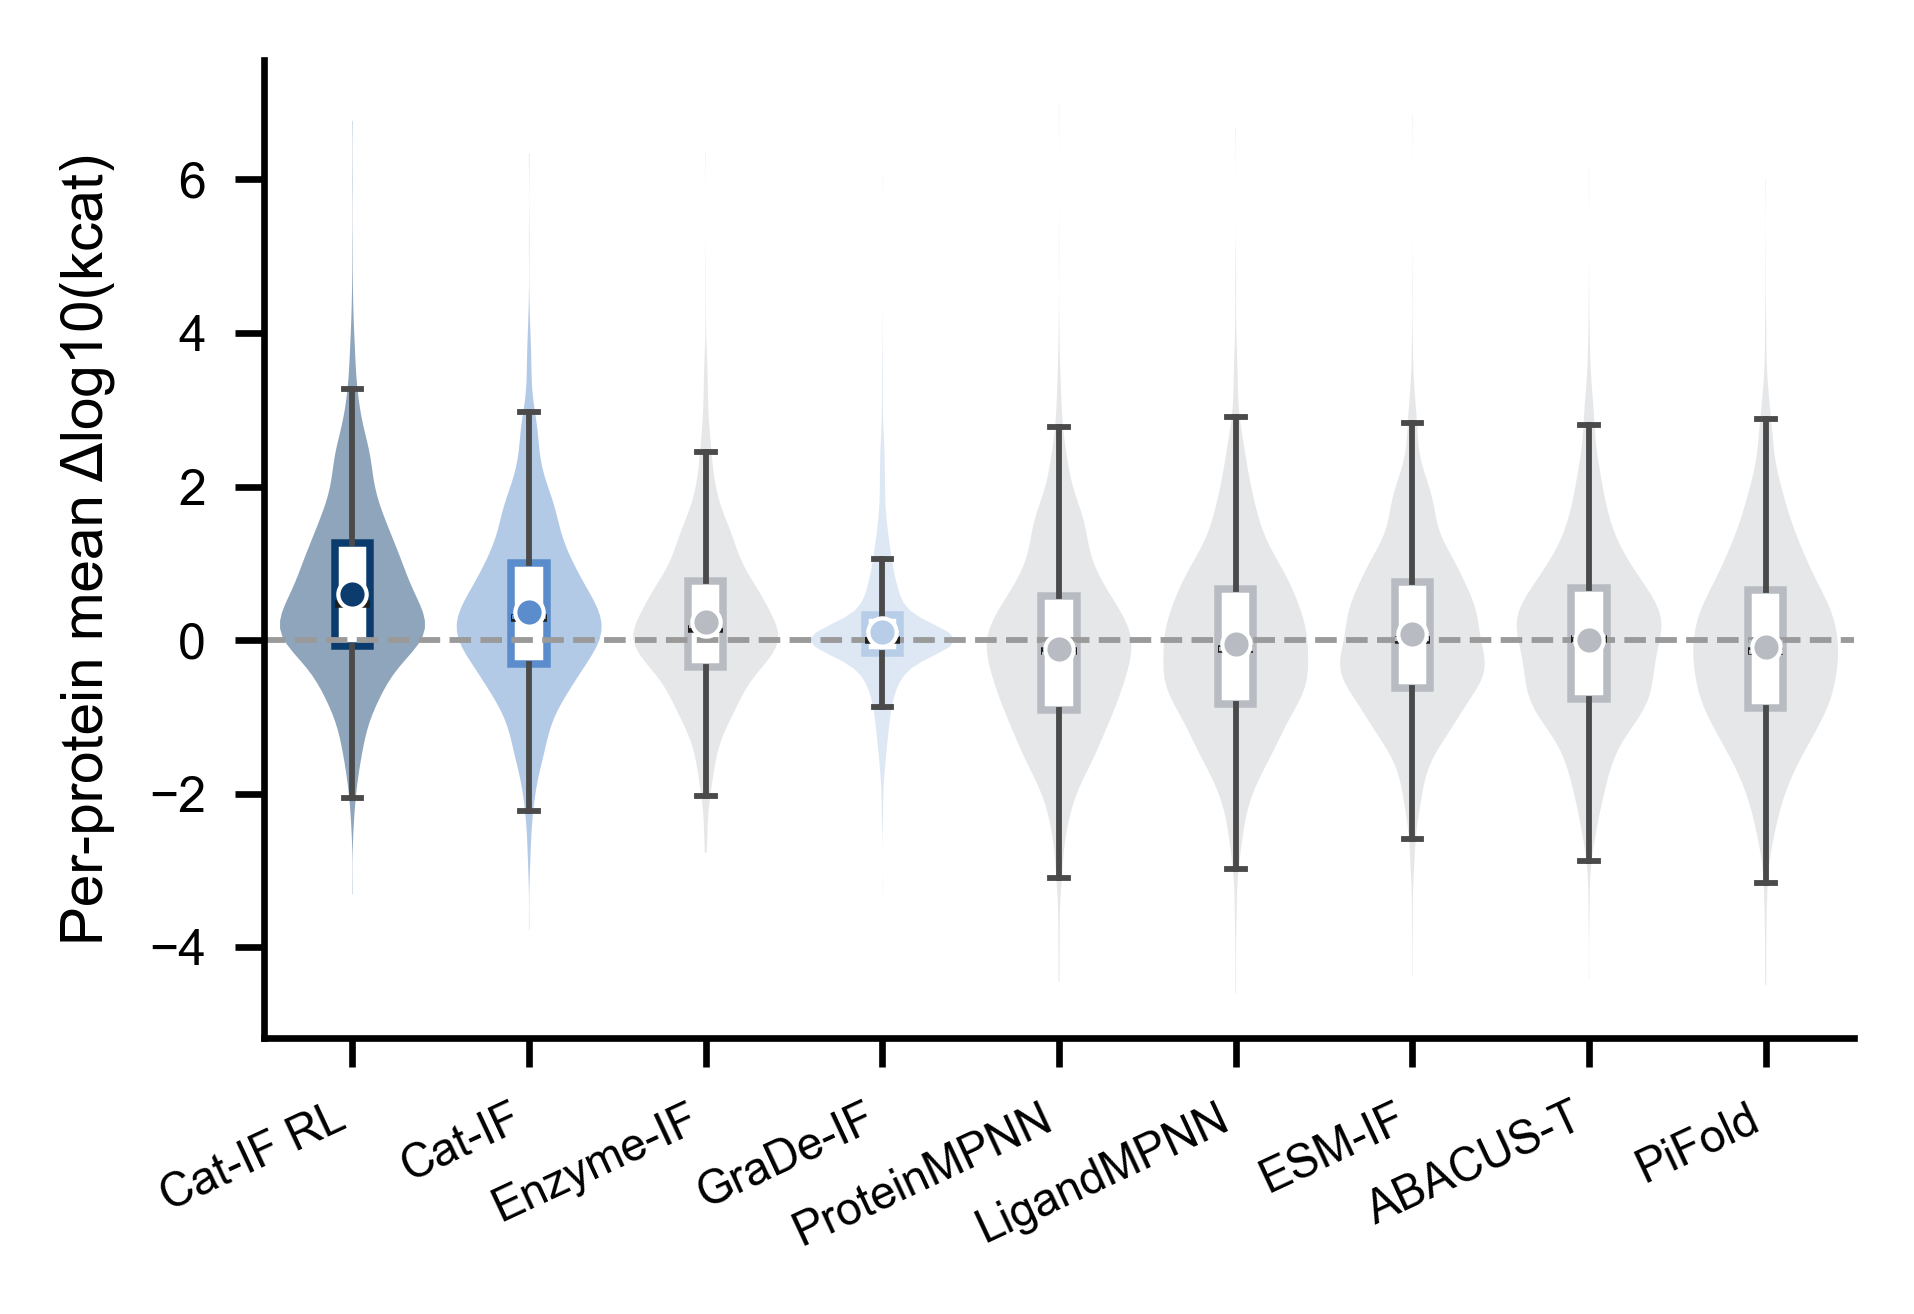

Figure width (inch): 3.20
Saved Figure 3A to: figure3_outputs/Figure3A_functional_shift.png
Saved Figure 3A to: figure3_outputs/Figure3A_functional_shift.pdf


In [16]:
# Figure 3A: 主功能指标分布图（per-protein mean Δlog10(kcat)）
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 5.5,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
})

if "model_data" not in globals() or not model_data:
    raise ValueError("请先运行上方数据汇总单元，确保 model_data 已生成。")

FIG3_OUTPUT_DIR = Path(globals().get("FIG3_OUTPUT_DIR", "figure3_outputs"))
FIG3_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIG3_MODEL_NAME_MAP = {
    "catif_rl_round3": "Cat-IF RL",
    "catif": "Cat-IF",
    "enzymeif": "Enzyme-IF",
    "gradeif": "GraDe-IF",
    "proteinmpnn": "ProteinMPNN",
    "ligandmpnn": "LigandMPNN",
    "esmif": "ESM-IF",
    "abacust": "ABACUS-T",
    "pifold": "PiFold",
}

FIG3_ORDER_A = [
    "catif_rl_round3",
    "catif",
    "enzymeif",
    "gradeif",
    "proteinmpnn",
    "ligandmpnn",
    "esmif",
    "abacust",
    "pifold",
]

FIG3_COLOR_MAP = {
    "gradeif": "#B7CDE8",
    "catif": "#5B8CCB",
    "catif_rl_round3": "#0B3C6D",
}
FIG3_BASELINE_COLOR = "#B8BCC2"

plot_records = []
for model_key in FIG3_ORDER_A:
    if model_key not in model_data:
        continue
    clean_df = model_data[model_key].get("clean_df", pd.DataFrame())
    if not isinstance(clean_df, pd.DataFrame) or clean_df.empty:
        continue
    if not {"proid", "delta_lgkcat"}.issubset(clean_df.columns):
        continue

    per_protein = (
        clean_df[["proid", "delta_lgkcat"]]
        .dropna()
        .assign(proid=lambda d: d["proid"].astype(str))
        .groupby("proid", as_index=False)["delta_lgkcat"]
        .mean()
    )
    if per_protein.empty:
        continue
    per_protein["model_key"] = model_key
    per_protein["Model"] = FIG3_MODEL_NAME_MAP.get(model_key, model_key)
    plot_records.append(per_protein)

if not plot_records:
    raise ValueError("Figure 3A 无可用数据，请检查 model_data 中各模型的 clean_df。")

plot_df = pd.concat(plot_records, ignore_index=True)
available_order = [k for k in FIG3_ORDER_A if k in plot_df["model_key"].unique()]
if not available_order:
    raise ValueError("Figure 3A 无可用模型数据。")

labels = [FIG3_MODEL_NAME_MAP.get(k, k) for k in available_order]
data = [
    pd.to_numeric(
        plot_df.loc[plot_df["model_key"] == model_key, "delta_lgkcat"],
        errors="coerce",
    ).dropna().values
    for model_key in available_order
]
positions = np.arange(1, len(available_order) + 1)

fig, ax = plt.subplots(figsize=(3.2, 2.2), dpi=600)

violin = ax.violinplot(
    data,
    positions=positions,
    widths=0.82,
    showmeans=False,
    showmedians=False,
    showextrema=False,
)
for body, model_key in zip(violin["bodies"], available_order):
    color = FIG3_COLOR_MAP.get(model_key, FIG3_BASELINE_COLOR)
    body.set_facecolor(color)
    body.set_edgecolor("none")
    body.set_alpha(0.46 if model_key in FIG3_COLOR_MAP else 0.35)

box = ax.boxplot(
    data,
    positions=positions,
    widths=0.20,
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "#1E1E1E", "linewidth": 0.9},
    whiskerprops={"color": "#4A4A4A", "linewidth": 0.7},
    capprops={"color": "#4A4A4A", "linewidth": 0.7},
)
for patch, model_key in zip(box["boxes"], available_order):
    patch.set_facecolor("white")
    patch.set_edgecolor(FIG3_COLOR_MAP.get(model_key, FIG3_BASELINE_COLOR))
    patch.set_linewidth(0.9)

for position, values, model_key in zip(positions, data, available_order):
    arr = np.asarray(values, dtype=float)
    if arr.size == 0:
        continue
    mean = float(np.nanmean(arr))
    if arr.size > 1:
        sem = float(np.nanstd(arr, ddof=1) / np.sqrt(arr.size))
        ci95 = 1.96 * sem
    else:
        ci95 = np.nan

    ax.errorbar(
        position,
        mean,
        yerr=ci95 if np.isfinite(ci95) else 0.0,
        fmt="o",
        ms=3.4,
        color=FIG3_COLOR_MAP.get(model_key, FIG3_BASELINE_COLOR),
        mec="white",
        mew=0.5,
        capsize=2,
        zorder=5,
    )

ax.axhline(0, linestyle="--", linewidth=0.7, color="#9A9A9A")
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("Per-protein mean Δlog10(kcat)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

fig.tight_layout()
out_png = FIG3_OUTPUT_DIR / "Figure3A_functional_shift.png"
out_pdf = FIG3_OUTPUT_DIR / "Figure3A_functional_shift.pdf"
fig.savefig(out_png, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()

print(f"Figure width (inch): {fig.get_size_inches()[0]:.2f}")
print(f"Saved Figure 3A to: {out_png}")
print(f"Saved Figure 3A to: {out_pdf}")

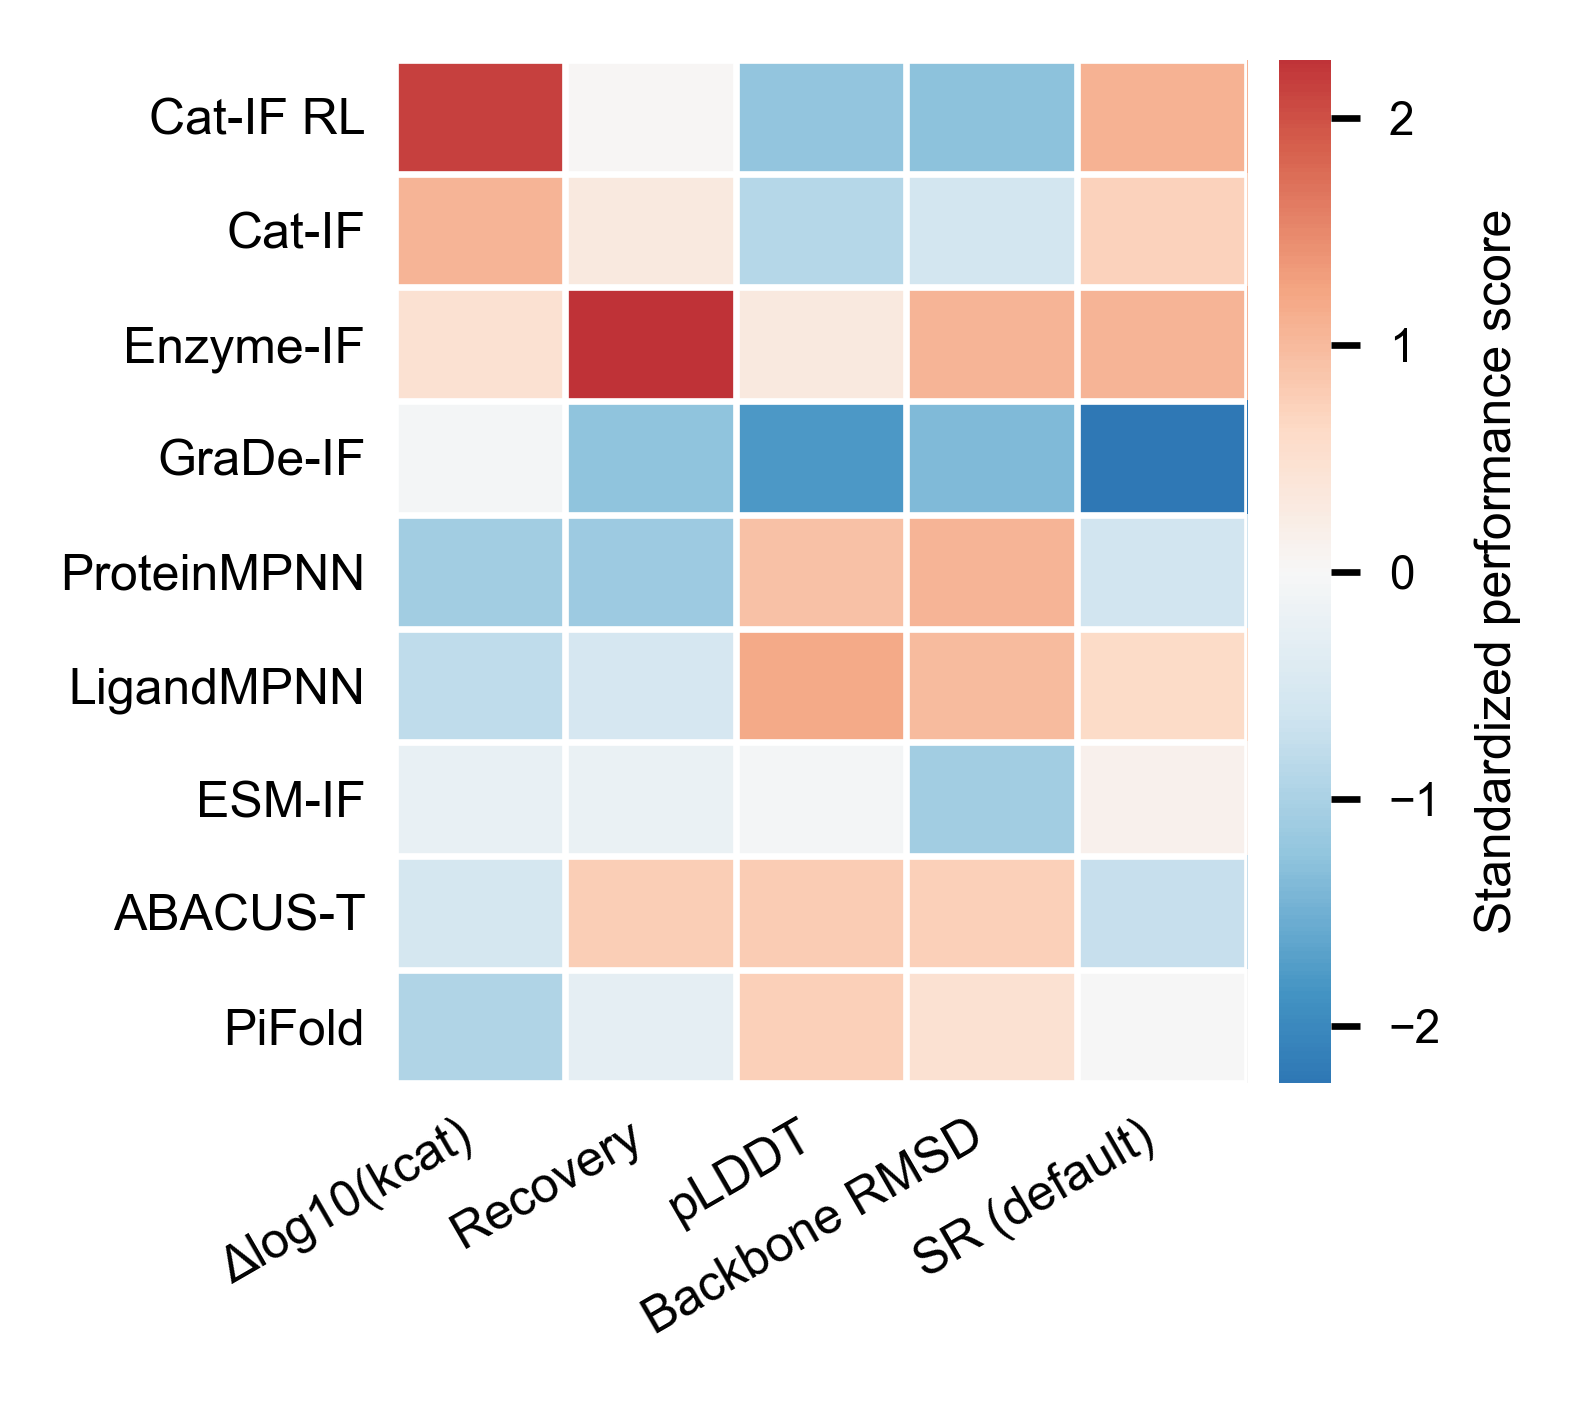

Figure width (inch): 3.20
Heatmap cell aspect set to width:height ≈ 1.5:1 via aspect=2/3
Saved Figure 3B to: figure3_outputs/Figure3B_tradeoff_heatmap.png
Saved Figure 3B to: figure3_outputs/Figure3B_tradeoff_heatmap.pdf


In [17]:
# Figure 3B: 结构–功能–保守性综合对比（compact heatmap）
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
})

if "metrics_overview_df" not in globals() or metrics_overview_df.empty:
    raise ValueError("请先运行上方汇总单元，确保 metrics_overview_df 已生成。")
if "sr_summary_df" not in globals() or sr_summary_df.empty:
    raise ValueError("请先运行上方汇总单元，确保 sr_summary_df 已生成。")

if "FIG3_MODEL_NAME_MAP" not in globals():
    FIG3_MODEL_NAME_MAP = {
        "gradeif": "GraDe-IF",
        "catif": "Cat-IF",
        "enzymeif": "Enzyme-IF",
        "catif_rl_round3": "Cat-IF RL",
        "proteinmpnn": "ProteinMPNN",
        "ligandmpnn": "LigandMPNN",
        "esmif": "ESM-IF",
        "abacust": "ABACUS-T",
        "pifold": "PiFold",
    }
if "FIG3_ORDER_A" not in globals():
    FIG3_ORDER_A = [
        "catif_rl_round3",
        "catif",
        "enzymeif",
        "gradeif",
        "proteinmpnn",
        "ligandmpnn",
        "esmif",
        "abacust",
        "pifold",
    ]
if "FIG3_OUTPUT_DIR" not in globals():
    from pathlib import Path

    FIG3_OUTPUT_DIR = Path("figure3_outputs")
    FIG3_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

default_sr_label = f"{PLDDT_THRESHOLD}/{RMSD_THRESHOLD}/0".replace(" ", "")

rows = []
for model_key in FIG3_ORDER_A:
    metrics_row = metrics_overview_df.loc[metrics_overview_df["model"] == model_key]
    if metrics_row.empty:
        continue
    metrics_row = metrics_row.iloc[0]

    sr_values = pd.to_numeric(
        sr_summary_df.loc[
            (sr_summary_df["model"] == model_key)
            & (
                sr_summary_df["label"].astype(str).str.replace(" ", "", regex=False)
                == default_sr_label
            ),
            "success_rate",
        ],
        errors="coerce",
    ).dropna()
    sr_default = float(sr_values.mean()) if len(sr_values) else np.nan

    rows.append(
        {
            "Model": FIG3_MODEL_NAME_MAP.get(model_key, model_key),
            "mean_deltalgkcat": float(metrics_row.get("delta_mean_per_proid", np.nan)),
            "Recovery": float(metrics_row.get("avg_recovery_rate", np.nan)),
            "pLDDT": float(metrics_row.get("overall_avg_plddt", np.nan)),
            "Backbone RMSD": float(metrics_row.get("avg_backbone_rmsd_mean", np.nan)),
            "SR (default)": sr_default,
        }
    )

raw_df = pd.DataFrame(rows).set_index("Model")
if raw_df.empty:
    raise ValueError("Figure 3B 无可用数据。")

def _zscore(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    if s.dropna().empty:
        return pd.Series(np.zeros(len(s)), index=s.index)
    std = float(s.std(ddof=0))
    if not np.isfinite(std) or std == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - float(s.mean())) / std

score_df = pd.DataFrame(index=raw_df.index)
score_df["Δlog10(kcat)"] = _zscore(raw_df["mean_deltalgkcat"])
score_df["Recovery"] = _zscore(raw_df["Recovery"])
score_df["pLDDT"] = _zscore(raw_df["pLDDT"])
score_df["Backbone RMSD"] = -_zscore(raw_df["Backbone RMSD"])
score_df["SR (default)"] = _zscore(raw_df["SR (default)"])

matrix = score_df.values.astype(float)
vmax = float(np.nanmax(np.abs(matrix))) if np.isfinite(np.nanmax(np.abs(matrix))) else 1.0
if vmax == 0:
    vmax = 1.0

fig, ax = plt.subplots(figsize=(3.2, 2.35), dpi=600)
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

base_cmap = plt.get_cmap("RdBu_r")
light_cmap = LinearSegmentedColormap.from_list(
    "RdBu_r_light",
    base_cmap(np.linspace(0.14, 0.86, 256)),
)
im = ax.imshow(matrix, cmap=light_cmap, norm=norm, aspect=2/3)

ax.set_xticks(np.arange(score_df.shape[1]))
ax.set_xticklabels(score_df.columns)
for tick in ax.get_xticklabels():
    tick.set_rotation(30)
    tick.set_ha("right")

ax.set_yticks(np.arange(score_df.shape[0]))
ax.set_yticklabels(score_df.index)

for i in range(matrix.shape[0] + 1):
    ax.axhline(i - 0.5, color="white", linewidth=0.8)
for j in range(matrix.shape[1] + 1):
    ax.axvline(j - 0.5, color="white", linewidth=0.8)

ax.tick_params(axis="both", which="both", length=0)

for side in ["top", "right", "left", "bottom"]:
    ax.spines[side].set_visible(False)

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Standardized performance score", fontsize=6)
cbar.ax.tick_params(labelsize=5.5)
cbar.outline.set_visible(False)
for side in ["top", "right", "left", "bottom"]:
    cbar.ax.spines[side].set_visible(False)

fig.tight_layout()
out_png = FIG3_OUTPUT_DIR / "Figure3B_tradeoff_heatmap.png"
out_pdf = FIG3_OUTPUT_DIR / "Figure3B_tradeoff_heatmap.pdf"
fig.savefig(out_png, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()

print(f"Figure width (inch): {fig.get_size_inches()[0]:.2f}")
print("Heatmap cell aspect set to width:height ≈ 1.5:1 via aspect=2/3")
print(f"Saved Figure 3B to: {out_png}")
print(f"Saved Figure 3B to: {out_pdf}")

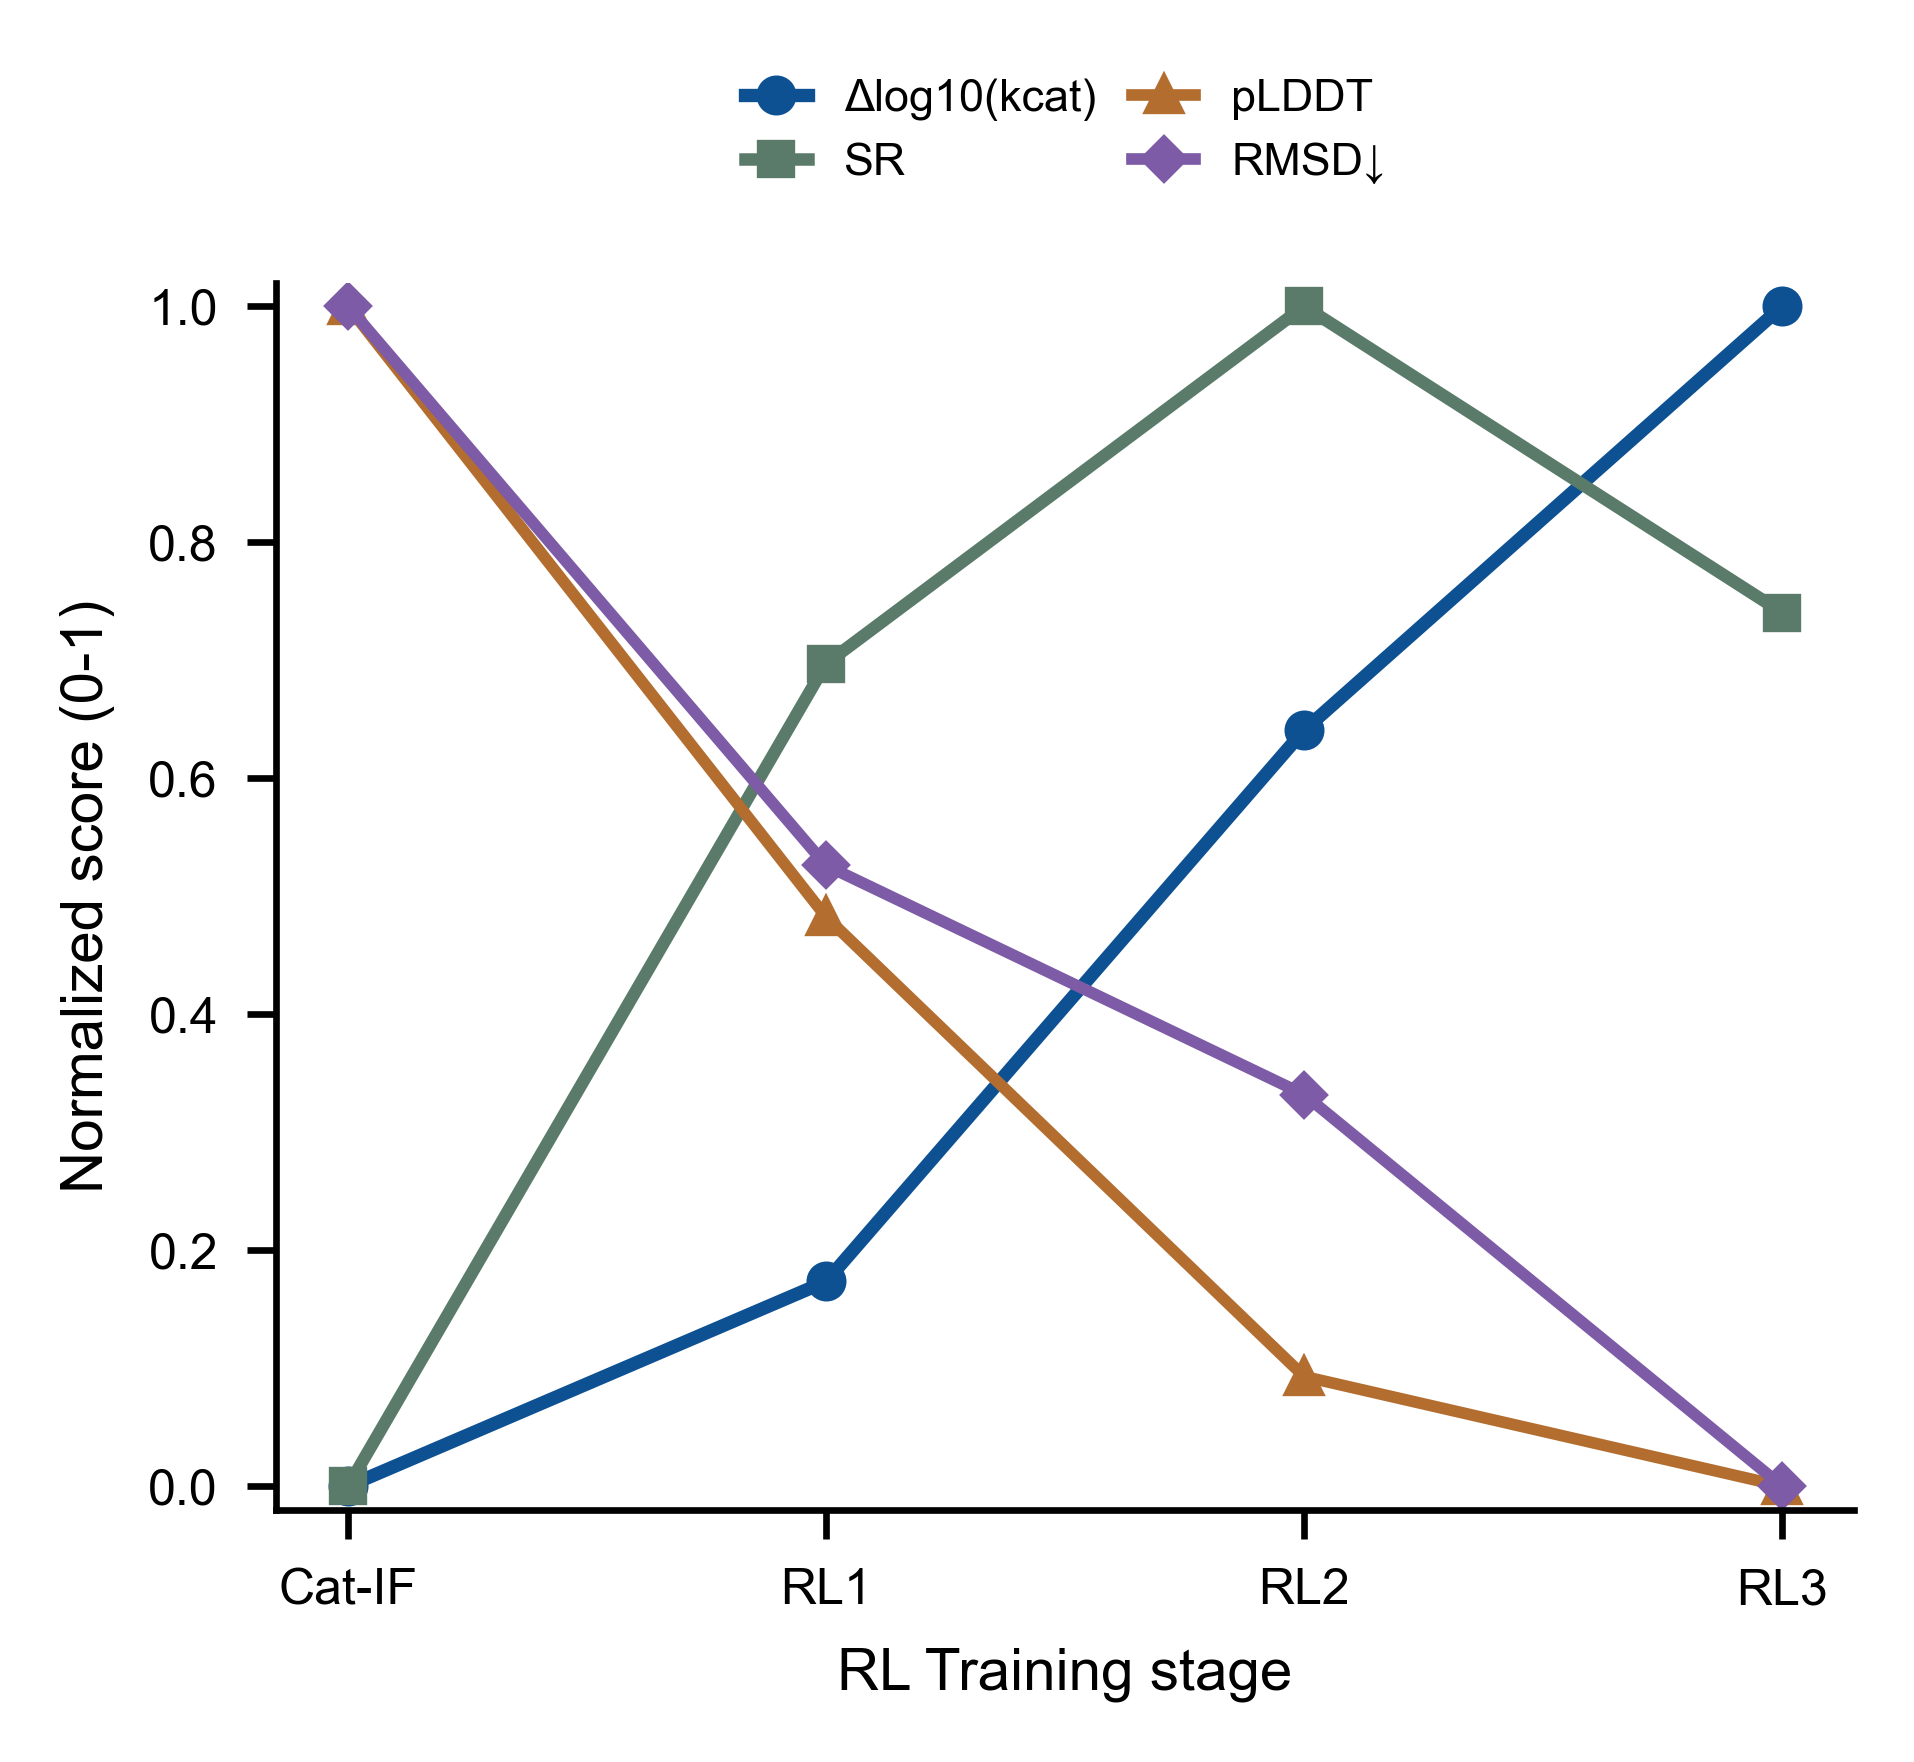

Figure width (inch): 3.20
Saved Figure 3C to: figure3_outputs/Figure3C_round_tradeoff_multi_metric_norm.png
Saved Figure 3C to: figure3_outputs/Figure3C_round_tradeoff_multi_metric_norm.pdf

Raw metric values by stage:


,stage,delta_mean_per_proid,default_SR,avg_pLDDT,avg_backbone_RMSD
0,Cat-IF,0.364655,0.114547,79.157807,4.885025
1,RL1,0.406339,0.125879,78.493275,5.092289
2,RL2,0.518600,0.130802,77.993177,5.177204
3,RL3,0.604866,0.126582,77.873768,5.322398


In [18]:
# Figure 3C: RL rounds 多指标动态 trade-off（单轴归一化折线）
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 5.4,
})

if "metrics_overview_df" not in globals() or metrics_overview_df.empty:
    raise ValueError("请先运行上方汇总单元，确保 metrics_overview_df 已生成。")
if "sr_summary_df" not in globals() or sr_summary_df.empty:
    raise ValueError("请先运行上方汇总单元，确保 sr_summary_df 已生成。")
if "FIG3_OUTPUT_DIR" not in globals():
    from pathlib import Path

    FIG3_OUTPUT_DIR = Path("figure3_outputs")
    FIG3_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

round_models = ["catif", "catif_rl_round1", "catif_rl_round2", "catif_rl_round3"]
round_labels = ["Cat-IF", "RL1", "RL2", "RL3"]
default_sr_label = f"{PLDDT_THRESHOLD}/{RMSD_THRESHOLD}/0".replace(" ", "")

def _minmax_norm(values):
    arr = np.asarray(values, dtype=float)
    finite = np.isfinite(arr)
    if not finite.any():
        return np.full_like(arr, np.nan, dtype=float)
    vmin = np.nanmin(arr)
    vmax = np.nanmax(arr)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax == vmin:
        out = np.full_like(arr, 0.5, dtype=float)
        out[~finite] = np.nan
        return out
    out = (arr - vmin) / (vmax - vmin)
    out[~finite] = np.nan
    return out

delta_points = []
sr_points = []
plddt_points = []
rmsd_points = []

for model_key in round_models:
    m_row = metrics_overview_df.loc[metrics_overview_df["model"] == model_key]
    if m_row.empty:
        delta_points.append(np.nan)
        plddt_points.append(np.nan)
        rmsd_points.append(np.nan)
    else:
        row = m_row.iloc[0]
        delta_points.append(float(row.get("delta_mean_per_proid", np.nan)))
        plddt_points.append(float(row.get("overall_avg_plddt", np.nan)))
        rmsd_points.append(float(row.get("avg_backbone_rmsd_mean", np.nan)))

    sr_values = pd.to_numeric(
        sr_summary_df.loc[
            (sr_summary_df["model"] == model_key)
            & (
                sr_summary_df["label"].astype(str).str.replace(" ", "", regex=False)
                == default_sr_label
            ),
            "success_rate",
        ],
        errors="coerce",
    ).dropna()
    sr_points.append(float(sr_values.mean()) if len(sr_values) else np.nan)

x = np.arange(len(round_labels))

# 归一化到同一纵轴（0-1），并把 RMSD 转为 higher-is-better
delta_norm = _minmax_norm(delta_points)
sr_norm = _minmax_norm(sr_points)
plddt_norm = _minmax_norm(plddt_points)
rmsd_better_norm = _minmax_norm(-np.asarray(rmsd_points, dtype=float))

fig, ax = plt.subplots(figsize=(3.2, 3.0), dpi=600)

ax.plot(x, delta_norm, marker="o", linewidth=1.6, markersize=3.8, color="#0E5193", label="Δlog10(kcat)")
ax.plot(x, sr_norm, marker="s", linewidth=1.5, markersize=3.5, color="#5A7B69", label="SR")
ax.plot(x, plddt_norm, marker="^", linewidth=1.4, markersize=3.5, color="#B26D2F", label="pLDDT")
ax.plot(x, rmsd_better_norm, marker="D", linewidth=1.4, markersize=3.2, color="#7D5BA6", label="RMSD↓")

ax.set_xticks(x)
ax.set_xticklabels(round_labels)
ax.set_xlabel("RL Training stage")
ax.set_ylabel("Normalized score (0-1)")
ax.set_ylim(-0.02, 1.02)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.2), ncol=2, handlelength=1.4, columnspacing=0.8)

fig.tight_layout()
out_png = FIG3_OUTPUT_DIR / "Figure3C_round_tradeoff_multi_metric_norm.png"
out_pdf = FIG3_OUTPUT_DIR / "Figure3C_round_tradeoff_multi_metric_norm.pdf"
fig.savefig(out_png, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()

print(f"Figure width (inch): {fig.get_size_inches()[0]:.2f}")
print(f"Saved Figure 3C to: {out_png}")
print(f"Saved Figure 3C to: {out_pdf}")

print("\nRaw metric values by stage:")
raw_table = pd.DataFrame(
    {
        "stage": round_labels,
        "delta_mean_per_proid": delta_points,
        "default_SR": sr_points,
        "avg_pLDDT": plddt_points,
        "avg_backbone_RMSD": rmsd_points,
    }
)
raw_table

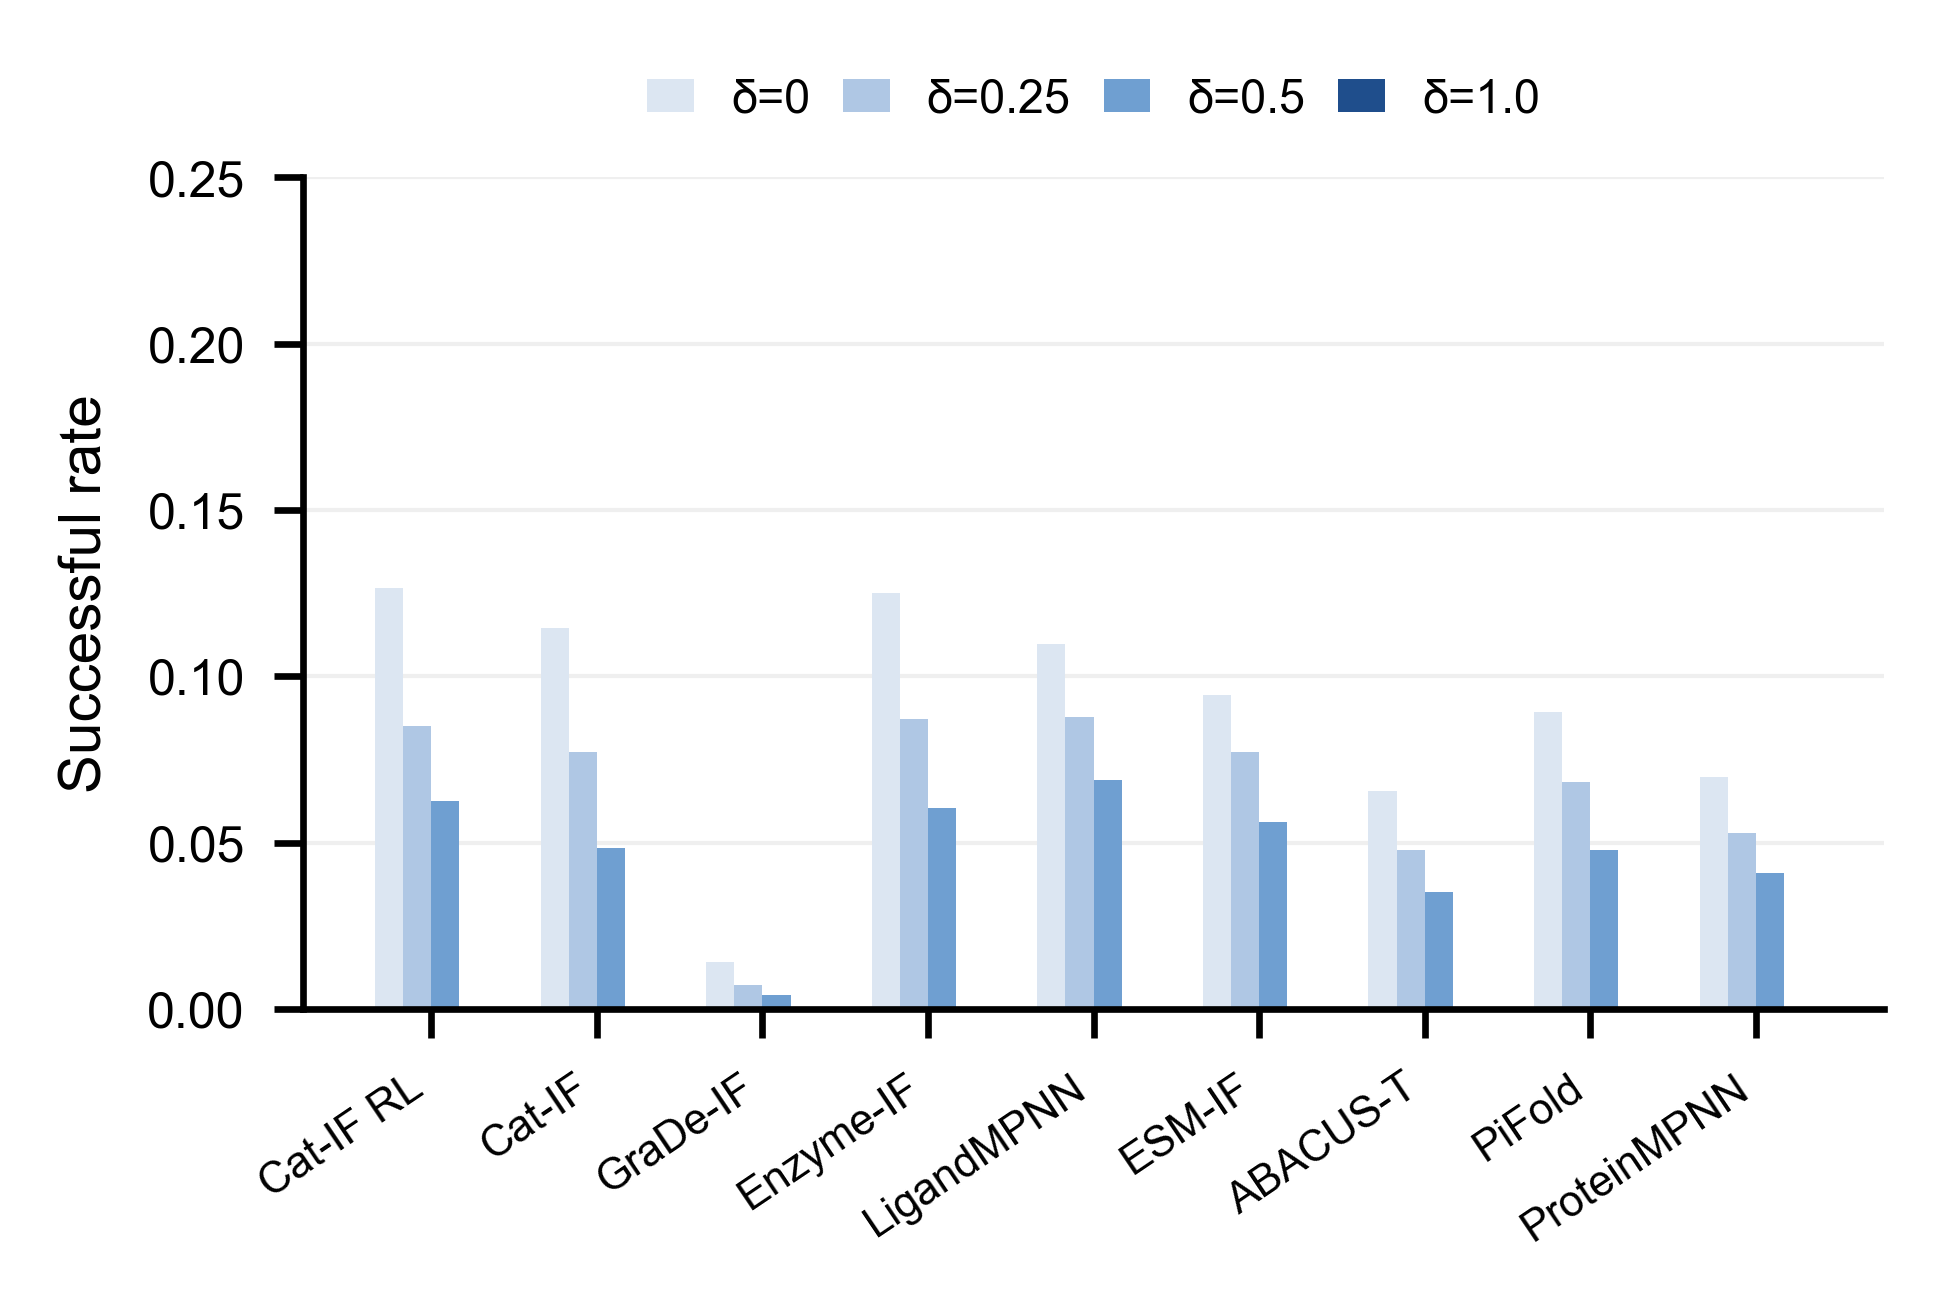

Figure width (inch): 3.25
Saved Figure 3D to: figure3_outputs/Figure3D_sr_by_delta_grouped_bar.png
Saved Figure 3D to: figure3_outputs/Figure3D_sr_by_delta_grouped_bar.pdf


In [19]:
# Figure 3D: 不同 δ 阈值下的 SR 分组柱状图
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 5.2,
    "ytick.labelsize": 6,
    "legend.fontsize": 5.6,
})

if "sr_summary_df" not in globals() or sr_summary_df.empty:
    raise ValueError("请先运行上方汇总单元，确保 sr_summary_df 已生成。")
if "FIG3_OUTPUT_DIR" not in globals():
    from pathlib import Path

    FIG3_OUTPUT_DIR = Path("figure3_outputs")
    FIG3_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if "FIG3_MODEL_NAME_MAP" not in globals():
    FIG3_MODEL_NAME_MAP = {
        "gradeif": "GraDe-IF",
        "catif": "Cat-IF",
        "enzymeif": "Enzyme-IF",
        "catif_rl_round3": "Cat-IF RL",
        "proteinmpnn": "ProteinMPNN",
        "ligandmpnn": "LigandMPNN",
        "esmif": "ESM-IF",
        "abacust": "ABACUS-T",
        "pifold": "PiFold",
    }

main_models = [
    "catif_rl_round3",
    "catif",
    "gradeif",
    "enzymeif",
    "ligandmpnn",
    "esmif",
    "abacust",
    "pifold",
    "proteinmpnn",
]

delta_list = [0, 0.25, 0.5, 1.0]
label_by_delta = {
    delta: f"{PLDDT_THRESHOLD}/{RMSD_THRESHOLD}/{delta}".replace(" ", "")
    for delta in delta_list
}

records = []
for model_key in main_models:
    for delta in delta_list:
        sr_vals = pd.to_numeric(
            sr_summary_df.loc[
                (sr_summary_df["model"] == model_key)
                & (
                    sr_summary_df["label"].astype(str).str.replace(" ", "", regex=False)
                    == label_by_delta[delta]
                ),
                "success_rate",
            ],
            errors="coerce",
        ).dropna()
        records.append(
            {
                "model": model_key,
                "delta": delta,
                "success_rate": float(sr_vals.mean()) if len(sr_vals) else np.nan,
            }
        )

sr_df = pd.DataFrame(records)
pivot_df = sr_df.pivot(index="model", columns="delta", values="success_rate")
available_models = [m for m in main_models if m in pivot_df.index]
pivot_df = pivot_df.reindex(available_models)

if pivot_df.empty:
    raise ValueError("Figure 3D 无可用数据。")

x = np.arange(len(available_models))
width = 0.17
offsets = np.linspace(-1.5 * width, 1.5 * width, num=len(delta_list))
colors = ["#DCE6F2", "#AFC7E4", "#6F9FD1", "#1F4E8C"]

fig, ax = plt.subplots(figsize=(3.25, 2.25), dpi=600)
for idx, delta in enumerate(delta_list):
    y = pd.to_numeric(pivot_df[delta], errors="coerce").values
    y = np.nan_to_num(y, nan=0.0)
    ax.bar(
        x + offsets[idx],
        y,
        width=width,
        color=colors[idx],
        edgecolor="none",
        label=f"δ={delta}",
    )

ax.set_xticks(x)
ax.set_xticklabels([FIG3_MODEL_NAME_MAP.get(m, m) for m in available_models], rotation=34, ha="right")
ax.set_ylabel("Successful rate")

max_y = float(np.nanmax(pivot_df.values)) if np.isfinite(np.nanmax(pivot_df.values)) else 1.0
ax.set_ylim(0, min(1.0, max(0.25, max_y + 0.08)))

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.17),
    ncol=4,
    frameon=False,
    handlelength=1.0,
    columnspacing=0.7,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle="-", linewidth=0.5, alpha=0.20)
ax.set_axisbelow(True)

fig.tight_layout()
out_png = FIG3_OUTPUT_DIR / "Figure3D_sr_by_delta_grouped_bar.png"
out_pdf = FIG3_OUTPUT_DIR / "Figure3D_sr_by_delta_grouped_bar.pdf"
fig.savefig(out_png, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()

print(f"Figure width (inch): {fig.get_size_inches()[0]:.2f}")
print(f"Saved Figure 3D to: {out_png}")
print(f"Saved Figure 3D to: {out_pdf}")